# PyTUMs: Predicting NOVA Food Processing Groups & Nutri-Score Grades Using Open Food Facts Data

**Final Project — PyTUMs**

**Team & Contributions:** *(please fill in per section — required by the task sheet: "Please state your name for each part you have contributed.")*

| Section | Contributed by |
|---|---|
| 1. Domain Knowledge | *Bilal, Minh* |
| 2. Problem Statement & Hypotheses | *Bilal, Minh* |
| 3–8. Data Extraction, Cleaning, Preprocessing | *Bilal, Minh* |
| 9. EDA | *Bilal, Minh* |
| 10–11. ML Preprocessing & Clustering | *Niklas, Max* |
| 12–14. ML Models, Comparison, Tuning (NOVA) | *Niklas, Max* |
| 15. Nutri-Score (Secondary Problem) | *Niklas, Max* |
| 16. Conclusion | *Niklas, Max* |


## 1. Domain Knowledge

### 1.1 NOVA Classification (Main Focus)

The NOVA classification system categorizes foods according to the extent and purpose of industrial processing rather than nutrient composition alone (Monteiro et al., 2016). It distinguishes four groups: unprocessed or minimally processed foods, processed culinary ingredients, processed foods, and ultra-processed foods (Monteiro et al., 2016; Romero Ferreiro et al., 2021). 

- Group 1 includes foods such as fruit, vegetables, milk, grains, meat, or eggs (Monteiro et al., 2016; Sarda et al., 2024). 
- Group 2 consists of culinary ingredients such as oils, butter, sugar, or salt (Monteiro et al., 2016; Sarda et al., 2024).
- Group 3 includes processed foods such as cheese, canned vegetables, or freshly baked bread (Monteiro et al., 2016; Sarda et al., 2024).
- Group 4 contains ultra-processed food and drink products, which are typically industrial formulations with several ingredients, additives, and substances not commonly used in home cooking (Monteiro et al., 2016; Sarda et al., 2024).

NOVA is the main focus of this project because it captures a different dimension of food evaluation than nutrient-based labels. While nutrient profiling systems evaluate nutritional composition, NOVA focuses on food processing and industrial formulation (Romero Ferreiro et al., 2021; Sarda et al., 2024). This makes NOVA a more complex prediction target, because it is not directly calculated from values such as energy, sugar, saturated fat, or salt. Instead, NOVA depends more strongly on ingredient lists, additives, and processing-related characteristics (Monteiro et al., 2016; Menichetti et al., 2023). Therefore, this project uses NOVA groups as the main target variable and extends the nutrient-based features with additives_n and ingredients_n, which are conceptually closer to the NOVA definition.

<span style="color:green"><b>Important caveat, addressed in detail in Section 13.1: this reasoning applies to NOVA as a concept, as defined by Monteiro et al. (2016) through manual assessment of ingredients and processing methods. The `nova_group` column actually used in this project, however, is not manually assigned -- Open Food Facts computes it with its own rule-based algorithm, which itself relies substantially on a product's category and additive tags (see `Nova-Algorithmus_OpenFoodFacts.md` for details). Since `additives_n` and `main_category_grouped` are used as features here, part of the "target" is technically available as an input. Section 13.1 quantifies this by comparing model performance with and without these two features.</b></span>


### 1.2 Nutri-Score (Secondary Benchmark)

Nutri-Score is a front-of-pack nutrition label that classifies packaged food products from A to E, where A represents the most favorable nutritional profile and E the least favorable. The score is based on a nutrient profiling algorithm that balances unfavorable components, such as energy, saturated fat, sugar, and salt, with favorable components, such as fiber, protein, and fruit or vegetable content (van der Bend et al., 2022; Merz et al., 2024).

Nutri-Score is intended to simplify nutrition information and help consumers compare food products more easily. However, it should be interpreted carefully because products from different food groups naturally differ in their nutritional composition. Therefore, comparisons within similar product groups can be more meaningful than comparisons across very different categories (van der Bend et al., 2022; Merz et al., 2024). In 2023, the Nutri-Score algorithm was updated to better align with food-based dietary guidelines and to improve discrimination within selected product groups, especially for products high in sugar, salt, or saturated fat (Merz et al., 2024).

In this project, Nutri-Score is included as a secondary benchmark. Since it is directly based on nutritional components, it is expected to be more predictable from nutrient features than NOVA. Comparing both targets allows the project to examine how well the same product information predicts a nutrient-based label versus a processing-based label (Romero Ferreiro et al., 2021; Sarda et al., 2024.



## 2. Problem Statement, Project Goals & Hypotheses

### 2.1 Problem Statement & Project Goals

This project investigates whether food classification systems can be predicted from structured product information in the Open Food Facts dataset (Hugging Face, 2026). The main focus is the prediction of NOVA food processing groups. NOVA classifies foods according to the extent and purpose of industrial processing, which makes it conceptually different from nutrient-based food labels (Monteiro et al., 2016; Romero Ferreiro et al., 2021). Based on this disctinction, the project is guided by the following main research question: 

**Can the NOVA processing group of a food product be predicted from its nutrient values per 100 g, together with information on the number of additives and ingredients?**

As a secondary supervised learning problem, the project also predicts Nutri-Score grades from the same product information. Nutri-Score is included as a benchmark because it is directly based on nutritional components such as energy, sugar, saturated fat, salt, fiber, and protein (van der Bend et al., 2022; Merz et al., 2024). Comparing NOVA and Nutri-Score prediction therefore allows the project to examine whether the same feature set predicts a nutrient-based label and a processing-based label with different levels of accuracy.
In addition, the project includes an unsupervised learning component. Clustering is used to explore whether products can be grouped into meaningful product profiles based on nutrient values and whether these clusters resemble Nutri-Score or NOVA more closely. This helps assess whether nutritional patterns alone capture processing-related differences.

The main project goals are:
1. Build a cleaned and shuffled sample from the Open Food Facts dataset.
2. Develop domain knowledge on both NOVA and Nutri-Score and translate it into testable hypotheses.
3. Build, evaluate, and tune several machine learning models for NOVA classification, including ensemble and neural-network-based approaches.
4. Use Nutri-Score classification as a contrasting benchmark.
5. Apply clustering to examine whether nutrient-based product groups align more closely with Nutri-Score or NOVA.
6. Interpret the results using existing literature and discuss relevant dataset and methodological limitations.

### 2.2 Hypotheses

Based on the domain knowledge and previous literature, four testable hypotheses are formulated.

**H1: Products with a higher number of additives and ingredients are more likely to belong to NOVA group 4.**  
*This expectation follows from the NOVA definition of ultra-processed foods, which emphasizes industrial formulations, additives, and ingredients not commonly used in home cooking (Monteiro et al., 2016; Sarda et al., 2024). Previous machine learning studies also show that processing levels can be predicted from structured food product data, including nutrient and additive-related patterns (Menichetti et al., 2023).*

**H2: NOVA groups are expected to be more difficult to predict than Nutri-Score grades.**  
*Nutri-Score is directly based on nutrient values, whereas NOVA captures the degree of food processing and depends more strongly on ingredient lists, additives, and formulation characteristics (Monteiro et al., 2016; Merz et al., 2024). Therefore, the same nutrient-based feature set should predict Nutri-Score more accurately than NOVA.*

**H3: Nutri-Score and NOVA are related but not identical.**  
*A product can have a favorable nutritional profile while still being ultra-processed, or it can be less processed while receiving a less favorable Nutri-Score. Previous research shows that ultra-processed foods can appear across all Nutri-Score grades, indicating that nutritional quality and processing level represent complementary dimensions of food evaluation (Romero Ferreiro et al., 2021; Sarda et al., 2024).*

**H4: Nutrient-based clustering is expected to resemble Nutri-Score more closely than NOVA.**  
*Since the clustering features are mainly nutrient values, they are conceptually closer to the Nutri-Score logic than to the NOVA logic. NOVA depends more strongly on processing-related information, while Nutri-Score is directly derived from nutritional composition (van der Bend et al., 2022; Monteiro et al., 2016; Merz et al., 2024).*

These hypotheses guide the exploratory analysis, supervised classification models, clustering analysis, and final interpretation of the project results.


## 3. Project Setup and Library Imports

Install the project dependencies once before running this notebook (from the repository root):

```bash
pip install -r requirements.txt
```

All required packages are listed in `requirements.txt` (e.g. `datasets`, `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `scipy`, `pyarrow`).

In the next cell, we import all required Python libraries. The `datasets` library is used to load the Open Food Facts dataset directly from Hugging Face. Pandas and NumPy are used for data manipulation. Matplotlib and Seaborn are used for data visualization.

<span style="color:green"><b>We additionally import scikit-learn modules for preprocessing pipelines, clustering, and the six classification models used in Sections 10-14, since these building blocks were not yet part of the previous version of the notebook (which had not reached the modeling stage).</b></span>


In [ ]:
# Import data handling libraries
import pandas as pd
import numpy as np

# Standard library helpers needed for reservoir sampling and caching the raw sample
import os
import json
import random
from datetime import datetime

# Import Hugging Face dataset loader
from datasets import load_dataset

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn building blocks for preprocessing, clustering, and models
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    adjusted_rand_score, silhouette_score
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Reproducibility: fixed seed for the entire notebook run
SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 60)
print("Setup complete.")


/Users/maxseidlitz/1-CODING/TUM-Uni/PythonandAdvancedDataScience/Nutrition_PythonAdvDataScience/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


## 4. Dataset Access and Data Extraction

This project uses the Open Food Facts product database, accessed through Hugging Face. Open Food Facts is an open and collaborative food product database that contains product-level information on packaged foods, including nutritional values, ingredient lists, additives, product categories, Nutri-Score grades, and NOVA food processing groups. Previous studies have used Open Food Facts to examine the relationship between Nutri-Score and NOVA, showing that the database is suitable for comparing nutrient-based and processing-based food classification systems (Romero Ferreiro et al., 2021; Sarda et al., 2024).

The Open Food Facts database is very large and contains several million food products (Hugging Face, 2026). Therefore, the dataset is loaded in streaming mode. Streaming allows access to the data without downloading the full dataset at once, which is useful when working with large datasets or limited local storage (Hugging Face, 2026).

Because processing the complete dataset would be computationally expensive in a student notebook environment, this project uses a sample of food products. Sampling is a common strategy in big data analysis because it reduces computational burden while still enabling meaningful exploration and model development when the sample is sufficiently informative (Salloum et al., 2019).

<span style="color:green"><b>What changed here and why: the sampling method was replaced with reservoir sampling (Algorithm R), and the sample size was increased from 50,000 to 100,000 products. In the previous version, `dataset.shuffle(seed=SEED, buffer_size=50_000).take(50_000)` was used. On a streamed dataset, `shuffle()` only randomizes within a fixed-size in-memory buffer: it fills the buffer with the first `buffer_size` rows of the stream, then for every requested row swaps in a random buffer element and refills the gap from the next row of the stream. Because the previous buffer size exactly equaled the sample size, the result was effectively a random re-ordering of roughly the first 50,000-100,000 rows of the stream -- not a random sample of the multi-million-row database. If the underlying dump has any internal order (e.g. by country, submission date, or barcode range), this silently reproduces the exact ordering bias that shuffling was meant to remove, while looking randomized.</b></span>

<span style="color:green"><b>Reservoir sampling fixes this: the full stream is scanned once, and at every step each newly seen product replaces a uniformly random element already in the sample with probability `sample_size / rows_seen_so_far`. This guarantees that every product in the entire database has exactly the same probability of ending up in the final sample, regardless of its position in the stream. The trade-off is runtime: the complete dataset has to be streamed through once (which can take 30-90+ minutes depending on connection speed), instead of stopping after the first `buffer_size` rows. To avoid paying this cost on every notebook run, the resulting sample is cached to disk (see below) and reloaded directly on subsequent runs.</b></span>


In [2]:
# Load the Open Food Facts product database from Hugging Face in streaming mode
# Streaming avoids downloading the full multi-million-row dataset at once
dataset = load_dataset(
    "openfoodfacts/product-database",
    split="food",
    streaming=True
)
print("Dataset connection successful.")


'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/openfoodfacts/product-database/resolve/e74147ed0b881cb708e8a3ac2756c4c35a206363/food.parquet
Retrying in 1s [Retry 1/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/openfoodfacts/product-database/resolve/e74147ed0b881cb708e8a3ac2756c4c35a206363/food.parquet
Retrying in 2s [Retry 2/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/openfoodfacts/product-database/resolve/e74147ed0b881cb708e8a3ac2756c4c35a206363/food.parquet
Retrying in 4s [Retry 3/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/openfoodfacts/product-database/resolve/e74147ed0b881cb708e8a3ac2756c4c35a206363/food.parquet
Retrying in 8s [Retry 4/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/openfoodfacts/product-database/resolve/e74147ed0b881cb708e8a3

Dataset connection successful.


In [3]:
# Sample size increased from 50,000 to 100,000 on supervisor feedback ("more data would be better").
# Reduce this if a full reservoir-sampling pass becomes too slow on your machine/connection.
SAMPLE_SIZE = 100_000

# Local cache: the reservoir-sampling pass below streams through the *entire*
# database once, which is slow. We cache the result so this only has to run
# once per machine; every later run of this notebook (or by a teammate) can
# just reload the exact same sample from disk instead of re-streaming it.
# This also makes the sample a fixed, inspectable artifact: "this is the
# dataset we actually looked at", independent of what Open Food Facts serves
# on a later day.
RAW_SAMPLE_PATH = "openfoodfacts_raw_sample.parquet"
RAW_SAMPLE_META_PATH = "openfoodfacts_raw_sample_meta.json"

if os.path.exists(RAW_SAMPLE_PATH):
    df = pd.read_parquet(RAW_SAMPLE_PATH)
    print(f"Loaded cached raw sample from '{RAW_SAMPLE_PATH}': {df.shape}")
    if os.path.exists(RAW_SAMPLE_META_PATH):
        with open(RAW_SAMPLE_META_PATH) as f:
            print("Sampling metadata:", json.load(f))
else:
    # Reservoir sampling (Algorithm R): draws a uniform random sample of fixed
    # size from a stream of unknown/huge length without ever holding the full
    # stream in memory. Every product seen so far has exactly SAMPLE_SIZE / n_seen
    # probability of being in the reservoir at any point, which is what makes
    # the final sample a true random sample of the whole database (see the
    # markdown cell above for why the previous shuffle-buffer approach did not
    # have this property).
    rng = random.Random(SEED)
    reservoir = []
    n_seen = 0

    for row in dataset:
        n_seen += 1
        if len(reservoir) < SAMPLE_SIZE:
            reservoir.append(row)
        else:
            j = rng.randint(0, n_seen - 1)
            if j < SAMPLE_SIZE:
                reservoir[j] = row
        if n_seen % 250_000 == 0:
            print(f"...{n_seen:,} products streamed so far")

    df = pd.DataFrame(reservoir)

    # Parquet (not CSV) is used because several columns (e.g. 'nutriments',
    # 'categories_tags') hold nested lists/dicts. CSV would flatten these into
    # plain strings on reload, breaking all downstream extraction logic;
    # Parquet preserves the original nested structure.
    df.to_parquet(RAW_SAMPLE_PATH, index=False)

    with open(RAW_SAMPLE_META_PATH, "w") as f:
        json.dump({
            "sample_size": SAMPLE_SIZE,
            "rows_streamed_total": n_seen,
            "seed": SEED,
            "method": "reservoir sampling (Algorithm R) over the full streamed dataset",
            "created_at": datetime.now().isoformat(timespec="seconds"),
        }, f, indent=2)

    print(f"Reservoir sampling complete. Streamed {n_seen:,} products, kept {len(reservoir):,}.")
    print(f"Raw sample cached as Parquet: '{RAW_SAMPLE_PATH}' (metadata: '{RAW_SAMPLE_META_PATH}')")

print("Dataset shape:", df.shape)
df.head()


Loaded cached raw sample from 'openfoodfacts_raw_sample.parquet': (100000, 111)
Sampling metadata: {'sample_size': 100000, 'rows_streamed_total': 4610617, 'seed': 42, 'method': 'reservoir sampling (Algorithm R) over the full streamed dataset', 'created_at': '2026-07-16T15:09:36'}
Dataset shape: (100000, 111)


,additives_n,additives_tags,allergens_tags,brands_tags,brands,categories,categories_tags,categories_properties,checkers_tags,ciqual_food_name_tags,cities_tags,code,compared_to_category,complete,completeness,correctors_tags,countries_tags,created_t,creator,data_quality_errors_tags,data_quality_info_tags,data_quality_warnings_tags,data_sources_tags,environmental_score_data,environmental_score_grade,environmental_score_score,environmental_score_tags,editors,emb_codes_tags,emb_codes,...,packagings_complete,packaging_recycling_tags,packaging_shapes_tags,packaging_tags,packaging_text,packaging,packagings,photographers,popularity_key,popularity_tags,product_name,product_quantity_unit,product_quantity,purchase_places_tags,quantity,rev,scans_n,serving_quantity,serving_size,states_tags,stores_tags,stores,traces_tags,unique_scans_n,unknown_ingredients_n,unknown_nutrients_tags,vitamins_tags,with_non_nutritive_sweeteners,with_sweeteners,schema_version
0,2.0,"[en:e14xx, en:e325]",[en:eggs],[xx:maitre-coq],Maître CoQ,Farces,[en:stuffing],"{'ciqual_food_code': None, 'agribalyse_food_co...",[],[unknown],[chavagnes-en-paillers-vendee-france],3230890018107,en:stuffing,0,0.8625,"[ldc, fixbot, packbot]",[en:france],1549800655,ldc,[],"[en:no-packaging-data, en:ingredients-percent-...",[en:environmental-score-packaging-packaging-da...,"[producer-ldc, producers]","{""status"":""unknown"",""agribalyse"":{""warning"":""m...",unknown,NaN,[unknown],None,[emb-85065b],EMB 85065B,...,None,[],[],[en:fresh],[],Frais,[],None,0,None,"[{'lang': 'main', 'text': 'Farce cuisinée aux ...",g,400,None,400 g,6,NaN,NaN,NaN,"[en:to-be-completed, en:nutrition-facts-comple...",None,NaN,"[en:celery, en:gluten, en:milk, en:mustard, en...",NaN,1.0,[],[],NaN,NaN,1003
1,NaN,None,[],[xx:aldi-bio],Aldi Bio,NaN,None,"{'ciqual_food_code': None, 'agribalyse_food_co...",[],None,None,4061462577697,NaN,0,0.3000,[smoothie-app],[en:switzerland],1762503645,macrofactor,[],"[en:no-packaging-data, en:food-groups-1-unknow...",[en:serving-quantity-defined-but-quantity-unde...,"[app-macrofactor, apps, app-smoothie-openfoodf...","{""grade"":""unknown"",""missing"":{""categories"":1,""...",unknown,NaN,[unknown],None,None,NaN,...,None,[],[],None,[],NaN,[],None,0,None,"[{'lang': 'main', 'text': 'Muesli Dinkel Schok...",NaN,NaN,None,NaN,2,NaN,100,1 portion (100 g),"[en:to-be-completed, en:nutrition-facts-comple...",None,NaN,[],NaN,NaN,[],None,NaN,NaN,1003
2,NaN,None,[],[xx:Nutricost],Nutricost,NaN,None,"{'ciqual_food_code': None, 'agribalyse_food_co...",[],None,None,0810014673776,NaN,0,0.3750,[macrofactor],[en:united-states],1721090089,macrofactor,[],"[en:no-packaging-data, en:food-groups-1-unknow...","[en:serving-quantity-under-1g, en:serving-quan...","[app-macrofactor, apps]","{""agribalyse"":{""warning"":""missing_agribalyse_m...",unknown,NaN,[unknown],None,None,NaN,...,None,[],[],None,[],NaN,[],None,0,None,"[{'lang': 'main', 'text': 'Lycopene'}, {'lang'...",NaN,NaN,None,NaN,8,NaN,0.02,1 softgel (0.02 g),"[en:to-be-completed, en:nutrition-facts-comple...",None,NaN,[],NaN,NaN,[],None,NaN,NaN,1004
3,NaN,None,[],None,NaN,NaN,None,"{'ciqual_food_code': None, 'agribalyse_food_co...",[],None,None,2060010048971,NaN,0,0.2750,[roboto-app],[en:italy],1636673043,kiliweb,[en:nutrition-packaging-as-sold-100g-energy-va...,"[en:no-packaging-data, en:food-groups-1-unknow...",[en:nutrition-packaging-as-sold-100g-energy-va...,"[app-yuka, apps]","{""agribalyse"":{""warning"":""missing_agribalyse_m...",unknown,NaN,[unknown],None,None,NaN,...,None,[],[],None,[],NaN,[],None,0,None,"[{'lang': 'main', 'text': 'Jamon serrsmo'}, {'...",NaN,NaN,None,NaN,8,NaN,NaN,NaN,"[en:to-be-completed, en:nutrition-facts-comple...",None,NaN,[],NaN,NaN,[],None,NaN,NaN,1003
4,NaN,None,[],None,NaN,NaN,None,"{'ciqual_food_code': None, 'agribalyse_food_co...",[],[unknown],None,8410740914482,NaN,0,0.3750,[roboto-app],[en:spain],1579790524,kiliweb,[],"[en:no-packaging-data, en:food-groups-1-unknow...",[en:environmental-score-origins-of-ingredi

The reservoir-sampled products are cached locally as `openfoodfacts_raw_sample.parquet`, together with a small JSON metadata file (`openfoodfacts_raw_sample_meta.json`) recording the sample size, the random seed, and how many products were streamed in total to produce it. This means the (slow) full pass over the streamed database only has to run once per machine: every later run of this notebook reloads the identical sample from disk instead of re-streaming it. It also gives the project a fixed, documented answer to "what dataset did we actually analyze?", independent of the fact that Open Food Facts itself changes daily.

## 5. Initial Data Understanding

Before cleaning the data, the dataset structure is inspected. This includes checking the number of rows and columns, reviewing data types, displaying column names, and verifying whether the most important variables for the project are available.

The most relevant columns at this stage are nutriscore_grade and nutriments, which contains the nutritional information needed to create the model features. <span style="color:green"><b>In addition, we now inspect the NOVA-related columns (nova_group, nova_groups_tags, nova_groups), since NOVA is the new main target variable, and the countries_tags column, since Nutri-Score availability is strongly country-dependent, which helps explain part of the missingness in nutriscore_grade.</b></span>


In [4]:
print("Shape:", df.shape)
df.info()


Shape: (100000, 111)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 111 entries, additives_n to schema_version
dtypes: bool(1), float64(21), int64(6), object(56), str(27)
memory usage: 479.7+ MB


In [5]:
important_columns = ["product_name", "nutriscore_grade", "nutriscore_score", "nutriments"]
for col in important_columns:
    print(col, "exists:", col in df.columns)

df[important_columns].head()


product_name exists: True
nutriscore_grade exists: True
nutriscore_score exists: True
nutriments exists: True


,product_name,nutriscore_grade,nutriscore_score,nutriments
0,"[{'lang': 'main', 'text': 'Farce cuisinée aux ...",d,17.0,"[{'name': 'energy-kj', 'value': None, '100g': ..."
1,"[{'lang': 'main', 'text': 'Muesli Dinkel Schok...",unknown,NaN,"[{'name': 'sodium', 'value': None, '100g': 0.0..."
2,"[{'lang': 'main', 'text': 'Lycopene'}, {'lang'...",unknown,NaN,None
3,"[{'lang': 'main', 'text': 'Jamon serrsmo'}, {'...",unknown,NaN,"[{'name': 'energy-kcal', 'value': None, '100g'..."
4,"[{'lang': 'main', 'text': 'Pikotas'}, {'lang':...",unknown,NaN,"[{'name': 'fat', 'value': None, '100g': 0.0, '..."


The dataset contains the required columns for this project. The target variable nutriscore_grade is available, and the nutritional information is stored in the nested nutriments column. Since this column is not directly suitable for machine learning, the relevant nutrient values need to be extracted in a later step.

In [6]:
# check which NOVA-related columns exist and how they are populated.
# NOVA did not appear at all in the previous version of this notebook.
nova_related_cols = [c for c in ["nova_group", "nova_groups", "nova_groups_tags"] if c in df.columns]
print("Available NOVA columns:", nova_related_cols)

for col in nova_related_cols:
    print(f"\n--- {col} ---")
    print(df[col].head(10))
    print("Missing:", df[col].isna().sum(), "out of", len(df))


Available NOVA columns: ['nova_group', 'nova_groups', 'nova_groups_tags']

--- nova_group ---
0    4.0
1    NaN
2    NaN
3    NaN
4    NaN
5    4.0
6    NaN
7    NaN
8    NaN
9    NaN
Name: nova_group, dtype: float64
Missing: 75580 out of 100000

--- nova_groups ---
0      4
1    NaN
2    NaN
3    NaN
4    NaN
5      4
6    NaN
7    NaN
8    NaN
9    NaN
Name: nova_groups, dtype: str
Missing: 75580 out of 100000

--- nova_groups_tags ---
0    [en:4-ultra-processed-food-and-drink-products]
1                                         [unknown]
2                                         [unknown]
3                                         [unknown]
4                                         [unknown]
5    [en:4-ultra-processed-food-and-drink-products]
6                                         [unknown]
7                                         [unknown]
8                                         [unknown]
9                                         [unknown]
Name: nova_groups_tags, dtype: object


In [7]:
# distribution of the numeric NOVA group (if 'nova_group' is stored numerically)
if "nova_group" in df.columns:
    print(df["nova_group"].value_counts(dropna=False).sort_index())


nova_group
1.0     2866
2.0     1468
3.0     4537
4.0    15549
NaN    75580
Name: count, dtype: int64


In [8]:
# check whether Nutri-Score availability depends on the country
# ("something interesting to investigate" -- Nutri-Score is not shown in every country,
# which can explain why many rows have nutriscore_grade == 'unknown' even though
# nutrient values are present).
if "countries_tags" in df.columns:
    df_tmp = df.copy()
    df_tmp["has_nutriscore"] = df_tmp["nutriscore_grade"].isin(["a", "b", "c", "d", "e"])
    exploded = df_tmp.explode("countries_tags")
    availability_by_country = (
        exploded.groupby("countries_tags")["has_nutriscore"]
        .agg(["mean", "count"])
        .query("count >= 20")
        .sort_values("mean")
    )
    print("Nutri-Score availability by country (countries with >= 20 products only):")
    print(availability_by_country.head(15))


Nutri-Score availability by country (countries with >= 20 products only):
                                            mean  count
countries_tags                                         
en:pakistan                             0.000000     31
en:virgin-islands-of-the-united-states  0.000000     25
en:indonesia                            0.011111    180
en:japan                                0.012600    873
en:iraq                                 0.023438    128
en:russia                               0.024658    730
en:nicaragua                            0.025641     39
en:malaysia                             0.029126    103
en:cuba                                 0.030303     33
en:uzbekistan                           0.030303     33
en:nigeria                              0.043478     23
en:saudi-arabia                         0.047198    339
en:trinidad-and-tobago                  0.047619     21
en:kuwait                               0.049180     61
en:south-africa               

## 6. Target Variable Preparation: Nutri-Score & NOVA Group

The target variable nutriscore_grade contains the Nutri-Score class of each product. Since the goal is to predict valid Nutri-Score grades, only the classes A, B, C, D, and E are kept. Rows with values such as unknown or not-applicable are removed because they do not represent valid classes for the classification task.

<span style="color:green"><b>In addition, we now prepare a second target variable: the NOVA group (1-4). Because the previous notebook only prepared nutriscore_grade, this is entirely new. A normalization function is needed because the information can be encoded differently depending on the column (numeric in nova_group, or as a tag list such as ['en:4'] in nova_groups_tags). This handles possible format differences in the sample robustly, instead of simply discarding rows as was done for category data in the previous version.</b></span>


In [9]:
# --- Nutri-Score target variable ---
print("Distribution before cleaning:")
print(df["nutriscore_grade"].value_counts(dropna=False))

valid_grades = ["a", "b", "c", "d", "e"]
df_clean = df[df["nutriscore_grade"].isin(valid_grades)].copy()

print("\nOriginal shape:", df.shape)
print("Shape after Nutri-Score filter:", df_clean.shape)


Distribution before cleaning:
nutriscore_grade
unknown           67155
e                  8419
d                  7452
c                  6174
a                  4255
b                  3403
not-applicable     2192
NaN                 950
Name: count, dtype: int64

Original shape: (100000, 111)
Shape after Nutri-Score filter: (29703, 111)


After removing invalid Nutri-Score labels, the dataset only contains products with valid target classes. This ensures that the later machine learning models are trained on clearly defined categories.

In [10]:
# normalize and clean the NOVA target variable
def extract_nova_group(value):
    """
    Normalizes the raw NOVA group value to an integer 1-4 (or np.nan).

    Open Food Facts provides this information in different formats depending on
    the column:
    - numeric, e.g. 4.0 (column 'nova_group')
    - as a tag list, e.g. ['en:4'] (column 'nova_groups_tags')

    Parameters
    ----------
    value : float, int, list, or NaN
        Raw value from one of the NOVA columns.

    Returns
    -------
    int or np.nan
        The NOVA group (1-4) if it could be extracted validly, otherwise np.nan.
    """
    if value is None:
        return np.nan
    if isinstance(value, float) and np.isnan(value):
        return np.nan

    # Case 1: numeric value
    if isinstance(value, (int, float)):
        v = int(value)
        return v if v in [1, 2, 3, 4] else np.nan

    # Case 2: sequence of tags (list/tuple/ndarray after Parquet reload), e.g. ['en:4']
    if isinstance(value, (list, tuple, np.ndarray)) and len(value) > 0:
        tag = str(value[0])
        digits = "".join(ch for ch in tag if ch.isdigit())
        if digits.isdigit() and int(digits) in [1, 2, 3, 4]:
            return int(digits)

    return np.nan


# Primary source: numeric 'nova_group' column, if present
if "nova_group" in df.columns:
    df["nova_group_clean"] = df["nova_group"].apply(extract_nova_group)
else:
    df["nova_group_clean"] = np.nan

# Fallback: fill missing values from 'nova_groups_tags', if present
if "nova_groups_tags" in df.columns:
    missing_mask = df["nova_group_clean"].isna()
    df.loc[missing_mask, "nova_group_clean"] = df.loc[missing_mask, "nova_groups_tags"].apply(extract_nova_group)

print("NOVA group distribution after normalization:")
print(df["nova_group_clean"].value_counts(dropna=False).sort_index())


NOVA group distribution after normalization:
nova_group_clean
1.0     2866
2.0     1468
3.0     4537
4.0    15549
NaN    75580
Name: count, dtype: int64


In [11]:
# keep only valid NOVA groups (1-4)
df_clean_nova = df[df["nova_group_clean"].isin([1, 2, 3, 4])].copy()

print("Original shape:", df.shape)
print("Shape after NOVA filter:", df_clean_nova.shape)
print("\nDistribution:")
print(df_clean_nova["nova_group_clean"].value_counts().sort_index())


Original shape: (100000, 112)
Shape after NOVA filter: (24420, 112)

Distribution:
nova_group_clean
1.0     2866
2.0     1468
3.0     4537
4.0    15549
Name: count, dtype: int64


## 7. Nutrient Feature Extraction

The nutritional information in the Hugging Face version of the Open Food Facts dataset is stored inside the nested nutriments column. This column contains a list of dictionaries, where each dictionary represents one nutrient. For machine learning, this nested structure needs to be transformed into normal numerical columns. Therefore, selected nutrient values per 100g are extracted and stored as separate features.

The selected features are based on nutrients that are relevant for Nutri-Score classification. These include unfavorable components such as energy, fat, saturated fat, sugars, salt, and sodium, as well as more favorable components such as fiber and proteins (Bauer et al., 2013; Reynolds et al., 2019; Snetselaar et al., 2021; van der Bend et al., 2022; Merz et al., 2024; World Health Organization, 2026).

<span style="color:green"><b>In addition, we now also keep additives_n and ingredients_n (simple numeric columns already present in the dataset, no extraction from nested structures needed) as well as a simplified product category. This directly implements the feedback 'don't exclude variables we need for our prediction': in the previous version, category information was fully discarded after the EDA, even though it is more relevant for NOVA prediction (which is based on ingredients/categories) than for Nutri-Score.</b></span>


In [12]:
# Helpers for nested columns after Parquet reload:
# pyarrow/pandas often returns numpy.ndarray instead of Python list.
def as_sequence(value):
    """Normalize nested list-like values (list / tuple / ndarray) to a Python list."""
    if value is None:
        return []
    if isinstance(value, float) and np.isnan(value):
        return []
    if isinstance(value, (list, tuple, np.ndarray)):
        return list(value)
    if isinstance(value, (str, bytes)):
        return []
    try:
        return list(value)
    except TypeError:
        return []


def as_mapping(value):
    """Return a mapping-like object if possible, otherwise None."""
    if isinstance(value, dict):
        return value
    if hasattr(value, "get"):
        return value
    return None


def extract_nutrient_100g(nutriments, nutrient_name):
    """
    Extracts the 100g value of a specific nutrient from the nested nutriments column.

    Parameters:
    nutriments: list-like
        A sequence of dictionaries containing nutritional information.
        After Parquet reload this is often a numpy.ndarray, not a Python list.
    nutrient_name: str
        The name of the nutrient to extract.

    Returns:
    float or np.nan
        The nutrient value per 100g if available, otherwise np.nan.
    """
    for item in as_sequence(nutriments):
        mapping = as_mapping(item)
        if mapping is not None and mapping.get("name") == nutrient_name:
            return mapping.get("100g")
    return np.nan


nutrient_names = [
    "energy-kcal", "fat", "saturated-fat", "carbohydrates",
    "sugars", "fiber", "proteins", "salt", "sodium"
]

nutrient_features = [f"{n}_100g" for n in nutrient_names]


In [13]:
# a shared feature-extraction function so both target variables (Nutri-Score
# and NOVA) can reuse the same extracted features, instead of duplicating the
# extraction code as would happen with two separate pipelines.

def build_feature_frame(source_df):
    """Extracts nutrient, additive, ingredient, and category features from the raw dataset."""
    out = source_df.copy()

    for nutrient in nutrient_names:
        out[f"{nutrient}_100g"] = out["nutriments"].apply(lambda x: extract_nutrient_100g(x, nutrient))

    # additives_n and ingredients_n are already simple numeric columns in the raw
    # dataset -- relevant for NOVA, since additive/ingredient counts are a core criterion
    # of the NOVA definition.
    for col in ["additives_n", "ingredients_n"]:
        if col not in out.columns:
            out[col] = np.nan

    # simplified product category, instead of being fully discarded as before.
    # We take the last (most specific) category tag; non-informative values
    # ('en:undefined', 'en:null') are treated as missing.
    def extract_last_category(category_tags):
        tags = as_sequence(category_tags)
        if len(tags) == 0:
            return np.nan
        tag = tags[-1]
        if tag in ("en:undefined", "en:null"):
            return np.nan
        return tag

    if "categories_tags" in out.columns:
        out["main_category"] = out["categories_tags"].apply(extract_last_category)
    else:
        out["main_category"] = np.nan

    return out


df_features = build_feature_frame(df)

extended_numeric_features = nutrient_features + ["additives_n", "ingredients_n"]
print("Numeric feature columns:", extended_numeric_features)
df_features[extended_numeric_features + ["main_category"]].head()


Numeric feature columns: ['energy-kcal_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g', 'additives_n', 'ingredients_n']


,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,additives_n,ingredients_n,main_category
0,271.399994,19.0,8.1,11.0,6.8,2.2,13.0,1.20,0.480,2.0,16.0,en:stuffing
1,411.000000,12.0,5.7,60.0,15.0,7.6,12.0,0.07,0.028,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,232.000000,5.2,0.8,0.8,0.8,NaN,4.3,13.00,5.200,NaN,NaN,NaN
4,370.000000,0.0,0.0,89.0,85.5,NaN,2.0,0.18,0.072,NaN,NaN,NaN


In [14]:
# Sanity check: after Parquet reload, nutrient extraction must yield real values
# (not all-NaN columns). If these counts are ~0, nested-type handling is broken.
print("Non-null nutrient values per column:")
print(df_features[nutrient_features].notna().sum())
print("\nNon-null main_category:", df_features["main_category"].notna().sum())
print("\nSample extracted nutrient rows:")
display(df_features[nutrient_features + ["main_category"]].head())


Non-null nutrient values per column:
energy-kcal_100g      71982
fat_100g              71314
saturated-fat_100g    66117
carbohydrates_100g    71390
sugars_100g           67469
fiber_100g            38231
proteins_100g         71426
salt_100g             62281
sodium_100g           62282
dtype: int64

Non-null main_category: 39400

Sample extracted nutrient rows:


,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,main_category
0,271.399994,19.0,8.1,11.0,6.8,2.2,13.0,1.20,0.480,en:stuffing
1,411.000000,12.0,5.7,60.0,15.0,7.6,12.0,0.07,0.028,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,232.000000,5.2,0.8,0.8,0.8,NaN,4.3,13.00,5.200,NaN
4,370.000000,0.0,0.0,89.0,85.5,NaN,2.0,0.18,0.072,NaN


In [15]:
# determine the top-N categories; all others are grouped into 'other'.
# This limits the cardinality for the later one-hot encoding to a manageable size.
TOP_N_CATEGORIES = 15

top_categories = df_features["main_category"].value_counts().head(TOP_N_CATEGORIES).index.tolist()

df_features["main_category_grouped"] = df_features["main_category"].apply(
    lambda x: x if x in top_categories else ("missing" if pd.isna(x) else "other")
)

print(df_features["main_category_grouped"].value_counts())


main_category_grouped
missing                   60600
other                     32876
en:groceries               1330
en:beverages                821
en:snacks                   773
en:biscuits                 539
en:cheeses                  452
en:confectioneries          405
en:breads                   362
en:yogurts                  289
en:candies                  273
en:sweetened-beverages      264
en:honeys                   213
en:frozen-desserts          213
en:pastas                   201
en:virgin-olive-oils        199
en:frozen-foods             190
Name: count, dtype: int64


The selected nutrient values were successfully extracted into separate numerical columns. These columns now form the main feature set for the later machine learning models.

## 8. Data Cleaning and Preparation

After extracting the features, a smaller modeling dataset is created. It contains only the selected variables and the target variable(s). The cleaning process includes checking missing values, removing impossible or unrealistic values, and handling remaining missing values. These steps are necessary because Open Food Facts is a large open database and may contain inconsistent or user-generated entries (Hugging Face, 2026).

Missing values are checked because most machine learning models cannot handle missing numerical inputs directly. Identifying missing values helps decide whether values should be removed or replaced.

Because Open Food Facts is an open and partly user-generated database, some entries may contain unrealistic or incorrect nutritional values. Therefore, basic plausibility rules are applied. Negative nutrient values are removed, gram-based nutrients are limited to a maximum of 100g per 100g product, and energy values above 1000 kcal per 100g are treated as unrealistic. As in the previous version of this notebook, a row is dropped entirely if it violates any of these rules -- we keep this whole-row-drop approach rather than nulling out individual values.

<span style="color:green"><b>What changed here and why: the plausibility rules were extended with cross-nutrient consistency checks, since the original rules only ever looked at one column at a time and could not catch a value that is unrealistic only in combination with another. A row is now also dropped if: (1) sugars exceed total carbohydrates (sugars are by definition a subset of carbohydrates), (2) saturated fat exceeds total fat (same subset relationship), (3) the salt-to-sodium ratio deviates strongly from the fixed chemical conversion factor of 2.5 (salt = sodium x 2.5; a large deviation indicates a unit or transcription error), or (4) the three core macronutrients (fat, carbohydrates, proteins) sum to more than 100g per 100g product, which is physically impossible. In addition, rows with no usable nutrient value at all (all selected numeric columns missing) are removed, since these would otherwise be imputed later into an entirely fabricated "average product" instead of a real one. Finally, exact product duplicates (identified via the barcode column `code`) are removed, since Open Food Facts contains the same product multiple times (re-scans, resubmissions, near-duplicate country variants); without deduplication, the same product could end up in both the train and the test split later on, leaking information between them.</b></span>

<span style="color:green"><b>What changed here and why: Imputation of missing values is now moved to a later step -- instead of applying it here directly on the whole dataset, it now happens inside the scikit-learn Pipeline after the train/test split (Section 10), and is fit only on the training data. Reason: in the previous version, SimpleImputer.fit_transform() was applied to the entire df_model before any train/test split existed. This means median values computed from the later test set leaked into the training data (data leakage), which would make the test-set evaluation of the models optimistically biased. We fix this here, since it would otherwise distort the credibility of the later model comparisons.</b></span>


In [16]:
def apply_plausibility_filters(data, numeric_cols, gram_cols, energy_col, tolerance=1.0):
    """
    Applies plausibility rules to the extracted nutrient/additive features.

    A row that violates any rule is dropped entirely (same whole-row-drop
    approach as the previous version). `tolerance` (in grams) absorbs small
    rounding/measurement noise in the cross-nutrient checks below, so that
    e.g. a product with saturated-fat_100g slightly above fat_100g due to
    independent lab rounding is not treated the same as a genuine data-entry
    error.
    """
    out = data.copy()

    # Nutrient values per 100g should not be negative
    for col in numeric_cols:
        out = out[out[col].isna() | (out[col] >= 0)]

    # Gram-based nutrients should not exceed 100g per 100g product
    for col in gram_cols:
        out = out[out[col].isna() | (out[col] <= 100)]

    # Energy above 1000 kcal/100g is treated as unrealistic (likely a data-entry error)
    out = out[out[energy_col].isna() | (out[energy_col] <= 1000)]

    # --- Cross-nutrient consistency checks (new) ---

    # Sugars are a subset of total carbohydrates and therefore cannot exceed them.
    out = out[
        out["sugars_100g"].isna() | out["carbohydrates_100g"].isna()
        | (out["sugars_100g"] <= out["carbohydrates_100g"] + tolerance)
    ]

    # Saturated fat is a subset of total fat and therefore cannot exceed it.
    out = out[
        out["saturated-fat_100g"].isna() | out["fat_100g"].isna()
        | (out["saturated-fat_100g"] <= out["fat_100g"] + tolerance)
    ]

    # Salt and sodium describe the same underlying quantity via a fixed chemical
    # conversion factor (salt = sodium x 2.5). A large deviation from this ratio
    # points to a unit or transcription error rather than a real product.
    has_both = out["salt_100g"].notna() & out["sodium_100g"].notna() & (out["sodium_100g"] > 0)
    implied_ratio = out.loc[has_both, "salt_100g"] / out.loc[has_both, "sodium_100g"]
    bad_ratio_index = implied_ratio[~implied_ratio.between(2.5 * 0.5, 2.5 * 1.5)].index
    out = out.drop(index=bad_ratio_index)

    # The three core macronutrients (fat, carbohydrates, proteins) cannot sum
    # to more than 100g per 100g product.
    macro_sum = out[["fat_100g", "carbohydrates_100g", "proteins_100g"]].sum(axis=1, skipna=True)
    out = out[macro_sum <= 100 + tolerance]

    # Rows without a single usable nutrient value would otherwise be imputed
    # later into a fully fabricated "average product" rather than a real one.
    out = out[out[numeric_cols].notna().any(axis=1)]

    return out


gram_features = [f for f in nutrient_features if f != "energy-kcal_100g"]

print("Shape before plausibility filter:", df_features.shape)
df_features_clean = apply_plausibility_filters(
    df_features,
    numeric_cols=extended_numeric_features,
    gram_cols=gram_features,
    energy_col="energy-kcal_100g",
)
print("Shape after plausibility filter:", df_features_clean.shape)

# Deduplication (new): the same product (barcode) can appear multiple times in
# Open Food Facts. Without removing duplicates, the same product could end up
# in both the train and the test split in Section 10, leaking information
# between them and making the test-set evaluation optimistically biased.
if "code" in df_features_clean.columns:
    n_before = len(df_features_clean)
    df_features_clean = df_features_clean.drop_duplicates(subset="code", keep="first")
    print(f"Removed {n_before - len(df_features_clean)} duplicate products (by 'code'). "
          f"Shape after deduplication: {df_features_clean.shape}")
else:
    print("Column \'code\' not found in this sample -- skipping deduplication.")


Shape before plausibility filter: (100000, 123)
Shape after plausibility filter: (74839, 123)
Removed 0 duplicate products (by 'code'). Shape after deduplication: (74839, 123)


In [17]:
# Remaining missing values per column (imputation happens later, inside the ML pipeline, see Section 10)
df_features_clean[extended_numeric_features].isnull().sum()


energy-kcal_100g       3990
fat_100g               4655
saturated-fat_100g     9791
carbohydrates_100g     4575
sugars_100g            8458
fiber_100g            37504
proteins_100g          4539
salt_100g             13633
sodium_100g           13632
additives_n           47873
ingredients_n         47873
dtype: int64

In [18]:
# Final modeling datasets for both target variables
model_columns = extended_numeric_features + ["main_category_grouped"]

df_model_nova = df_features_clean[
    df_features_clean["nova_group_clean"].isin([1, 2, 3, 4])
][model_columns + ["nova_group_clean"]].copy()

df_model_nutri = df_features_clean[
    df_features_clean["nutriscore_grade"].isin(valid_grades)
][model_columns + ["nutriscore_grade"]].copy()

print("Final NOVA modeling dataset:", df_model_nova.shape)
print("Final Nutri-Score modeling dataset:", df_model_nutri.shape)

df_model_nova.to_csv("openfoodfacts_model_data_nova.csv", index=False)
df_model_nutri.to_csv("openfoodfacts_model_data_nutriscore.csv", index=False)


Final NOVA modeling dataset: (23406, 13)
Final Nutri-Score modeling dataset: (28924, 13)


## 9. Exploratory Data Analysis

Exploratory Data Analysis is used to better understand the cleaned dataset before building machine learning models. In this section, the distribution of the target variable(s) is examined, nutritional values are compared across classes, and correlations between numerical features are analyzed. The goal is to identify patterns, class imbalance, outliers, and relationships between nutritional variables.

<span style="color:green"><b>New in this section: the NOVA group distribution, average nutrient/additive values by NOVA group, and, most importantly, a cross-tabulation of Nutri-Score x NOVA group, which directly tests Hypothesis H3 and is likely what the supervisor meant by 'something particularly interesting to investigate' in this dataset.</b></span>

### 9.1 Distribution of the Target Variable(s)

First, the distribution of Nutri-Score grades is examined. This helps determine whether the classification problem is balanced or imbalanced.


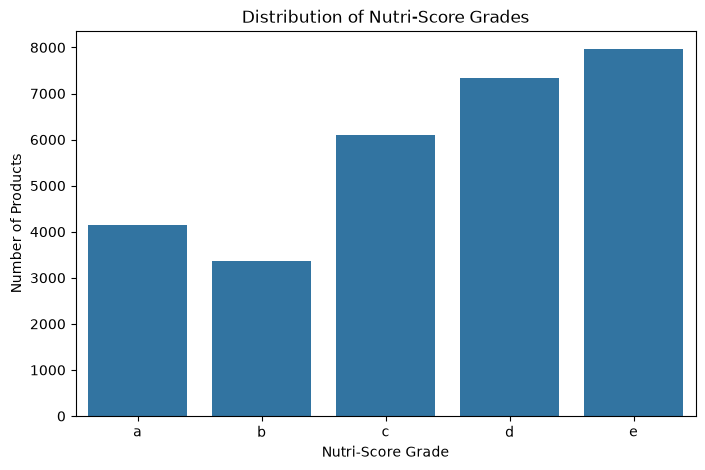

nutriscore_grade
a    14.35
b    11.64
c    21.12
d    25.37
e    27.51
Name: proportion, dtype: float64

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_model_nutri, x="nutriscore_grade", order=["a", "b", "c", "d", "e"])
plt.title("Distribution of Nutri-Score Grades")
plt.xlabel("Nutri-Score Grade")
plt.ylabel("Number of Products")
plt.show()

df_model_nutri["nutriscore_grade"].value_counts(normalize=True).sort_index().round(4) * 100


<span style="color:green"><b>Technique & rationale:</b></span> A countplot visualizes absolute frequencies per class and makes class imbalance immediately visible -- this is a prerequisite for choosing appropriate evaluation metrics later on (weighted F1-score instead of plain accuracy for imbalanced classes).

<span style="color:green"><b>Interpretation:</b></span> The cleaned sample (n = 28,924) is moderately imbalanced and skewed toward the unfavorable end: grade **E** is the most frequent class (27.5%), followed by **D** (25.4%) and **C** (21.1%), while **A** (14.4%) and especially **B** (11.6%) are under-represented. This is consistent with Open Food Facts being dominated by branded, packaged products, which more often carry unfavorable than favorable ratings, and with grade B occupying a narrow band of the underlying score scale. <span style="color:green"><b>Note that this distribution differs markedly from the previous version of this notebook, where grade A appeared far more frequent (24.6%). That earlier figure was an artifact of the biased buffer-based sample; under true reservoir sampling (Section 4), grade A drops to 14.4%.</b></span> This moderate imbalance is the reason weighted F1-score, not accuracy, is used to evaluate models in Sections 12-15.


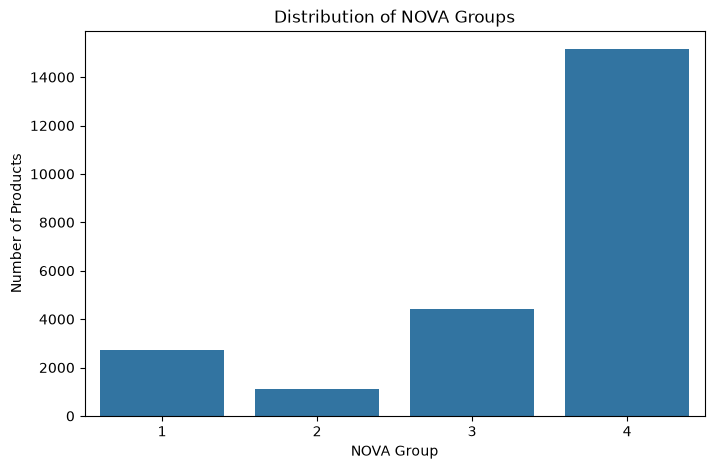

nova_group_clean
1    11.69
2     4.78
3    18.81
4    64.73
Name: proportion, dtype: float64

In [20]:
# distribution of the NOVA group
# Cast to int so seaborn categories match order=[1, 2, 3, 4]
df_model_nova_plot = df_model_nova.copy()
df_model_nova_plot["nova_group_clean"] = df_model_nova_plot["nova_group_clean"].astype(int)

plt.figure(figsize=(8, 5))
sns.countplot(data=df_model_nova_plot, x="nova_group_clean", order=[1, 2, 3, 4])
plt.title("Distribution of NOVA Groups")
plt.xlabel("NOVA Group")
plt.ylabel("Number of Products")
plt.show()

df_model_nova_plot["nova_group_clean"].value_counts(normalize=True).sort_index().round(4) * 100


<span style="color:green"><b>Interpretation:</b></span> The NOVA distribution is far more imbalanced than Nutri-Score: group **4** (ultra-processed) makes up **64.7%** of the cleaned sample (n = 23,406), group 3 accounts for 18.8%, group 1 for 11.7%, and group **2** for **4.8%**. This mirrors the wider literature: Monteiro et al. (2016) and later large-scale analyses of branded food databases consistently find that the large majority of packaged, barcoded products fall into NOVA group 4, since group 2 (processed culinary ingredients such as oil, sugar, or salt) is rarely sold as a distinct retail product in the way group 1, 3, and 4 items are. This imbalance is an important consideration for the classification task in Sections 12-14 and is revisited in the conclusion (Section 16). <span style="color:green"><b>Group 2 is, however, considerably better represented than in the previous version of this notebook (4.8% vs. 1.3%, i.e. 1,118 instead of a few hundred products). That earlier scarcity was largely an artifact of the biased sample rather than a property of the database: the true reservoir sample (Section 4) contains proportionally far more group 2 products, which makes the minority class usable for modeling instead of merely anecdotal.</b></span>


### 9.2 Summary Statistics of Nutritional Features

Summary statistics provide an overview of the numerical nutritional variables. They show the average values, standard deviations, and ranges of the selected features.

In [21]:
df_model_nova[nutrient_features].describe().round(2)


,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
count,21299.00,21286.00,20176.00,21279.00,20795.00,16004.00,21281.00,20822.00,20823.00
mean,277.77,14.34,5.20,29.62,14.07,2.90,7.56,1.25,0.50
std,199.67,19.58,8.22,27.96,19.96,4.91,8.94,4.90,1.96
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,100.00,0.60,0.10,4.67,0.90,0.00,1.00,0.04,0.02
50%,262.00,6.90,1.89,18.00,4.20,1.43,5.30,0.45,0.18
75%,405.00,21.43,7.30,54.00,20.00,3.60,10.34,1.22,0.49
max,1000.00,100.00,100.00,100.00,100.00,100.00,95.00,100.00,40.00


### 9.3 Average Nutritional Values by Nutri-Score Grade / NOVA Group

After inspecting the overall summary statistics, the next step is to compare the average nutritional values across classes. This helps identify whether products with less favorable classes show higher average levels of nutrients such as energy, fat, saturated fat, sugar, or salt.

                  energy-kcal_100g  fat_100g  saturated-fat_100g  \
nutriscore_grade                                                   
a                           172.47      5.26                0.82   
b                           215.00     14.47                2.29   
c                           201.00      9.65                2.43   
d                           304.94     16.33                6.27   
e                           385.23     21.38               10.17   

                  carbohydrates_100g  sugars_100g  fiber_100g  proteins_100g  \
nutriscore_grade                                                               
a                              20.04         2.72        4.45          10.59   
b                              14.88         2.53        1.91           5.84   
c                              21.27         6.37        2.85           6.54   
d                              28.70        12.55        2.79          10.24   
e                              39.96       

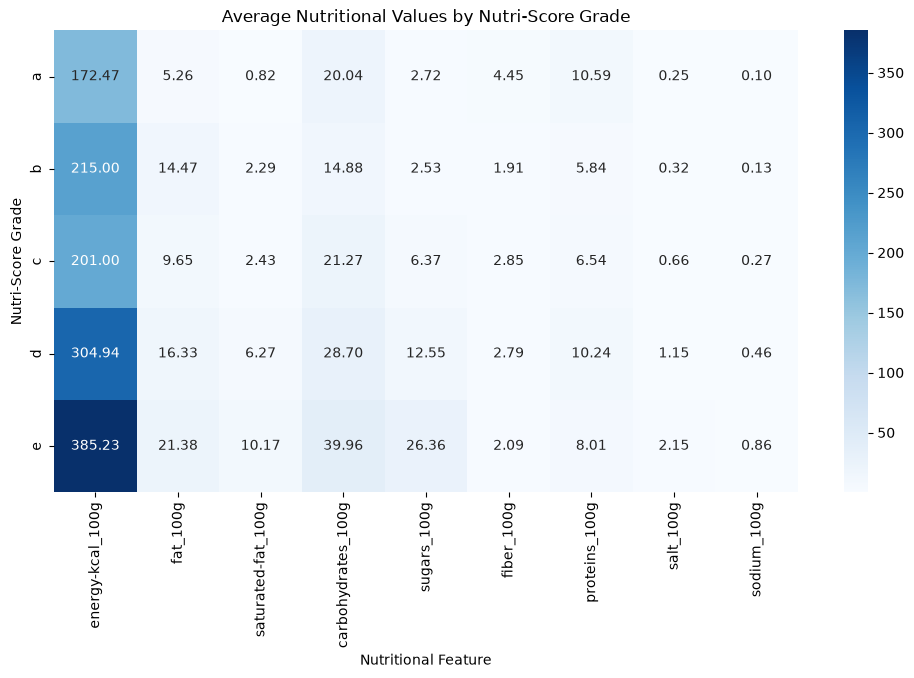

In [22]:
grade_means = df_model_nutri.groupby("nutriscore_grade")[nutrient_features].mean().round(2)
print(grade_means)

plt.figure(figsize=(12, 6))
sns.heatmap(grade_means, annot=True, fmt=".2f", cmap="Blues")
plt.title("Average Nutritional Values by Nutri-Score Grade")
plt.xlabel("Nutritional Feature")
plt.ylabel("Nutri-Score Grade")
plt.show()


<span style="color:green"><b>Technique & rationale:</b></span> The heatmap of grouped means shows whether the nutrient features vary systematically with the Nutri-Score grade -- this is the basis for expecting these features to be useful for classification.

<span style="color:green"><b>Interpretation:</b></span> The printed table and heatmap above confirm a clear, monotonic pattern: average energy, saturated fat, sugars, and salt all increase steadily from grade A to grade E, while grade A products show the lowest values across nearly every unfavorable nutrient. This is expected rather than a novel finding -- these are exactly the components that are penalized in the Nutri-Score formula itself (Merz et al., 2024), so the pattern is essentially a visual confirmation that the label captures what it is mathematically designed to capture. Protein and fiber (the favorable components) do not follow the same simple trend, since they depend more strongly on product category than on Nutri-Score grade.


                  energy-kcal_100g  fat_100g  saturated-fat_100g  \
nova_group_clean                                                   
1.0                         197.00      6.90                1.50   
2.0                         605.55     58.41               14.94   
3.0                         260.94     14.37                5.13   
4.0                         273.13     12.47                5.11   

                  carbohydrates_100g  sugars_100g  fiber_100g  proteins_100g  \
nova_group_clean                                                               
1.0                            25.35         6.35        4.67           7.86   
2.0                            22.79        19.14        0.80           0.83   
3.0                            22.40         7.54        3.03           9.77   
4.0                            33.05        17.01        2.56           7.33   

                  salt_100g  sodium_100g  additives_n  ingredients_n  
nova_group_clean                       

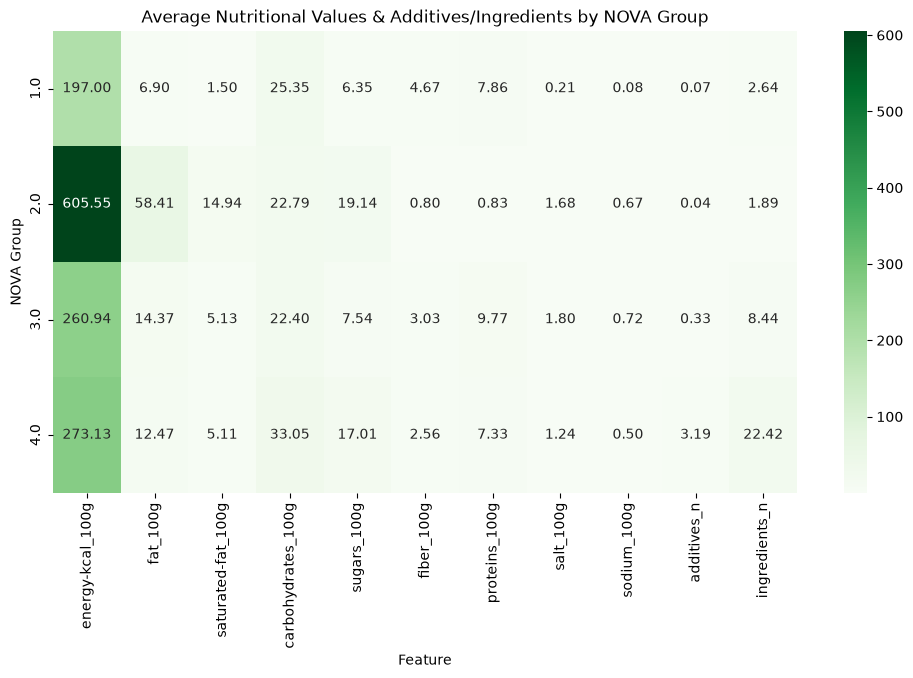

In [23]:
# average nutrient + additive/ingredient values by NOVA group
nova_means = df_model_nova.groupby("nova_group_clean")[extended_numeric_features].mean().round(2)
print(nova_means)

plt.figure(figsize=(12, 6))
sns.heatmap(nova_means, annot=True, fmt=".2f", cmap="Greens")
plt.title("Average Nutritional Values & Additives/Ingredients by NOVA Group")
plt.xlabel("Feature")
plt.ylabel("NOVA Group")
plt.show()


### 9.4 Correlation Analysis

A correlation analysis is used to examine relationships between the numerical nutritional features. This helps identify variables that are strongly related to each other, such as salt and sodium or fat and saturated fat. Understanding correlations is useful before machine learning because highly correlated features may contain overlapping information. This can be especially relevant for models such as Logistic Regression or K-Nearest Neighbors.

                    energy-kcal_100g  fat_100g  saturated-fat_100g  \
energy-kcal_100g                1.00      0.82                0.59   
fat_100g                        0.82      1.00                0.68   
saturated-fat_100g              0.59      0.68                1.00   
carbohydrates_100g              0.41     -0.13               -0.06   
sugars_100g                     0.26     -0.08                0.07   
fiber_100g                      0.23      0.06               -0.01   
proteins_100g                   0.20      0.10                0.10   
salt_100g                      -0.06     -0.04               -0.03   
sodium_100g                    -0.06     -0.04               -0.03   

                    carbohydrates_100g  sugars_100g  fiber_100g  \
energy-kcal_100g                  0.41         0.26        0.23   
fat_100g                         -0.13        -0.08        0.06   
saturated-fat_100g               -0.06         0.07       -0.01   
carbohydrates_100g             

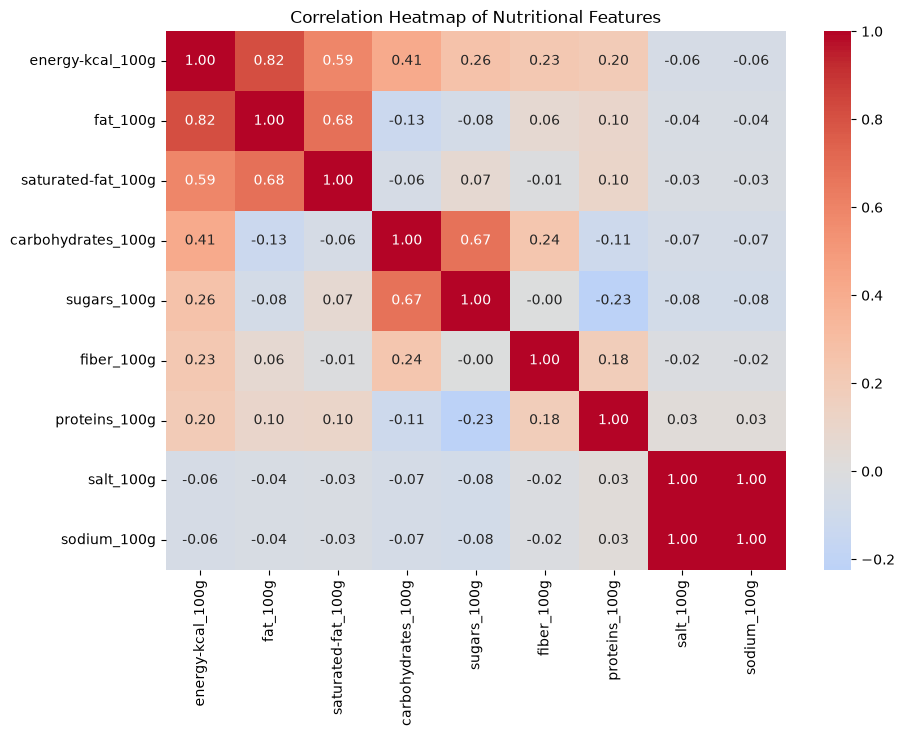

In [24]:
correlation_matrix = df_model_nova[nutrient_features].corr()
print(correlation_matrix.round(2))

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Nutritional Features")    
plt.show()


<span style="color:green"><b>Technique & rationale:</b></span> The correlation matrix identifies redundancy between features (e.g., salt/sodium, fat/saturated fat) -- relevant for model choice, since linear models like Logistic Regression are more sensitive to multicollinearity than tree-based models.

<span style="color:green"><b>Interpretation:</b></span> As expected from nutritional chemistry, salt and sodium are almost perfectly correlated (sodium is a direct component of salt), and fat is strongly correlated with both saturated fat and overall energy (fat contributes more energy per gram than carbohydrates or protein). Carbohydrates and sugars are also positively correlated, since sugars are a subset of total carbohydrates. These redundancies do not need to be removed manually: tree-based ensembles such as Random Forest and Gradient Boosting can split on either correlated feature without loss of information, which is one reason they were expected to outperform Logistic Regression in Sections 12 and 15 -- a expectation that is confirmed by the results.


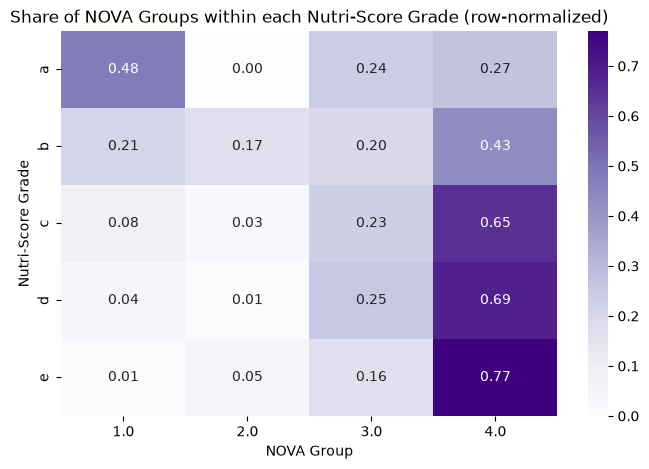

Number of products with BOTH valid target variables: 17787


nova_group_clean,1.0,2.0,3.0,4.0
nutriscore_grade,,,,
a,0.48,0.00,0.24,0.27
b,0.21,0.17,0.20,0.43
c,0.08,0.03,0.23,0.65
d,0.04,0.01,0.25,0.69
e,0.01,0.05,0.16,0.77


In [25]:
# cross-tabulation Nutri-Score x NOVA group
# Tests Hypothesis H3: are Nutri-Score and NOVA group independent dimensions,
# or does a good Nutri-Score automatically imply a low (good) NOVA group?
merged_targets = df_features_clean[
    df_features_clean["nutriscore_grade"].isin(valid_grades)
    & df_features_clean["nova_group_clean"].isin([1, 2, 3, 4])
][["nutriscore_grade", "nova_group_clean"]].copy()

crosstab_norm = pd.crosstab(
    merged_targets["nutriscore_grade"],
    merged_targets["nova_group_clean"],
    normalize="index"
).round(2)

plt.figure(figsize=(8, 5))
sns.heatmap(crosstab_norm, annot=True, fmt=".2f", cmap="Purples")
plt.title("Share of NOVA Groups within each Nutri-Score Grade (row-normalized)")
plt.xlabel("NOVA Group")
plt.ylabel("Nutri-Score Grade")
plt.show()

print(f"Number of products with BOTH valid target variables: {len(merged_targets)}")
crosstab_norm


<span style="color:green"><b>Interpretation:</b></span> The cross-tabulation provides clear empirical support for **Hypothesis H3**. Even among Nutri-Score **A** products, 27% are still classified as NOVA group 4 (ultra-processed), while 48% fall into the most favorable NOVA group 1. At the other end, 77% of Nutri-Score **E** products are NOVA group 4 -- but a non-trivial share of nominally "good" products is ultra-processed at every grade (n = 17,787 products with both labels valid).

This pattern is strikingly close to independently published findings on the same Open Food Facts database: Romero Ferreiro et al. (2021) report that ultra-processed foods (NOVA 4) make up 26.1% of Nutri-Score A products, rising to 83.7% of Nutri-Score E products; Sarda et al. (2024) similarly report a monotonically increasing share of NOVA 4 products from grade A to grade E using the French Open Food Facts subset. <span style="color:green"><b>Our own results (27% for A, 77% for E) follow the same monotonic direction and now match these published figures closely -- the value for grade A (27%) is almost identical to the 26.1% reported by Romero Ferreiro et al. (2021). This agreement is itself evidence that the reservoir sample introduced in Section 4 is representative: the previous, buffer-based sample produced 42% for grade A, which deviated substantially from the published literature. Replacing the sampling method moved our result onto the published value without any change to the analysis itself.</b></span>

**H3 is therefore confirmed:** nutritional quality (Nutri-Score) and degree of processing (NOVA) are related but clearly not collinear -- exactly the "complementary but distinct dimensions" that Sarda et al. (2024) describe.


For later machine learning, these correlations are important because highly correlated variables may provide overlapping information. However, tree-based models such as Random Forests can usually handle correlated features, while models such as Logistic Regression may be more sensitive to multicollinearity.

## 10. Preprocessing for Machine Learning

<span style="color:green"><b>The previous notebook version did not contain an ML pipeline yet. We build:

1. A train/test split (stratified by the target variable, so the class distribution is preserved).
2. A ColumnTransformer pipeline that imputes (median) and scales (StandardScaler) numeric features, and one-hot encodes the categorical main_category_grouped column. The key point: all transformations are fit only on the training data and then applied to the test data -- this prevents the data leakage described in Section 8.

The focus is on NOVA as the main problem; Nutri-Score is handled with a structurally identical but more compact pipeline in Section 15.</b></span>


In [26]:
# Features (X) and target (y) for the NOVA main problem
numeric_cols = extended_numeric_features
categorical_cols = ["main_category_grouped"]

X = df_model_nova[numeric_cols + categorical_cols]
y = df_model_nova["nova_group_clean"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nClass distribution (train):\n", y_train.value_counts(normalize=True).round(2))
print("\nClass distribution (test):\n", y_test.value_counts(normalize=True).round(2))


Train shape: (18724, 12)  Test shape: (4682, 12)

Class distribution (train):
 nova_group_clean
4    0.65
3    0.19
1    0.12
2    0.05
Name: proportion, dtype: float64

Class distribution (test):
 nova_group_clean
4    0.65
3    0.19
1    0.12
2    0.05
Name: proportion, dtype: float64


In [27]:
# ColumnTransformer: numeric features -> median imputation + scaling
#                      categorical features -> one-hot encoding
# Fit with .fit_transform() ONLY on X_train (inside each pipeline below),
# and applied with .transform() to X_test -- no leakage.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)


## 11. Clustering (Unsupervised Learning)

<span style="color:green"><b>This is a completely new section, directly requested in the supervisor feedback ("maybe we have opportunity to cluster the products"). We check whether products can be grouped into meaningful clusters using nutrient features alone -- and whether these clusters align more closely with Nutri-Score or with NOVA groups (Hypothesis H4).

For clustering we use only the numeric nutrient features (not additives_n/ingredients_n, since those are more NOVA-specific and we specifically want to test how well pure nutrient-based clusters align with both target variables).</b></span>


In [28]:
# Separate scaling for clustering (independent of the supervised train/test split,
# since clustering is unsupervised and performed on the entire cleaned dataset)
cluster_source = df_features_clean[
    df_features_clean["nutriscore_grade"].isin(valid_grades)
    & df_features_clean["nova_group_clean"].isin([1, 2, 3, 4])
].copy()

cluster_imputer = SimpleImputer(strategy="median")
cluster_scaler = StandardScaler()

X_cluster_imputed = cluster_imputer.fit_transform(cluster_source[nutrient_features])
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster_imputed)

print("Clustering dataset:", X_cluster_scaled.shape)


Clustering dataset: (17787, 9)


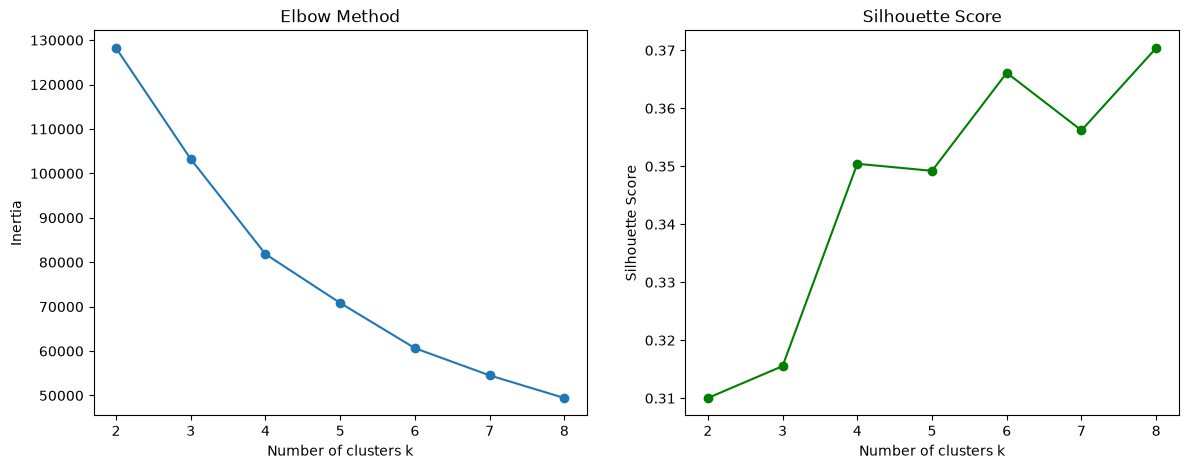

In [29]:
# Elbow method + silhouette score to determine a reasonable number of clusters k
inertia_values = []
silhouette_values = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertia_values, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette_values, marker="o", color="green")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette Score")
plt.show()


In [30]:
# Choose k: highest silhouette score (can be adjusted after running)
best_k = list(k_range)[int(np.argmax(silhouette_values))]
print("Chosen k (best silhouette score):", best_k)

kmeans_final = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
cluster_source["cluster"] = kmeans_final.fit_predict(X_cluster_scaled)


Chosen k (best silhouette score): 8


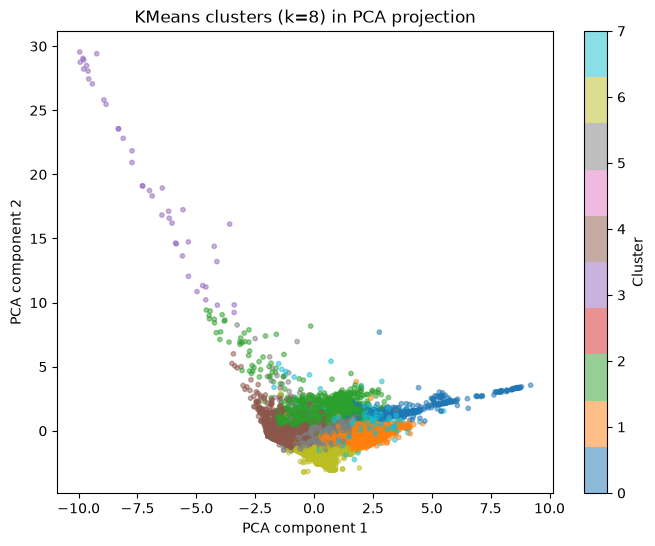

Explained variance by 2 PCA components: 51.18%


In [31]:
# PCA to 2 dimensions, for visualization only (not used for clustering itself)
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_source["cluster"], cmap="tab10", alpha=0.5, s=10)
plt.title(f"KMeans clusters (k={best_k}) in PCA projection")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

print(f"Explained variance by 2 PCA components: {pca.explained_variance_ratio_.sum():.2%}")


In [32]:
# Compare: cluster vs. Nutri-Score, and cluster vs. NOVA group (tests Hypothesis H4)
ari_nutriscore = adjusted_rand_score(cluster_source["nutriscore_grade"], cluster_source["cluster"])
ari_nova = adjusted_rand_score(cluster_source["nova_group_clean"], cluster_source["cluster"])

print(f"Adjusted Rand Index cluster vs. Nutri-Score: {ari_nutriscore:.3f}")
print(f"Adjusted Rand Index cluster vs. NOVA group: {ari_nova:.3f}")
print("\n(Higher values = stronger agreement. H4 expects: ARI with Nutri-Score > ARI with NOVA)")


Adjusted Rand Index cluster vs. Nutri-Score: 0.082
Adjusted Rand Index cluster vs. NOVA group: 0.030

(Higher values = stronger agreement. H4 expects: ARI with Nutri-Score > ARI with NOVA)


In [33]:
# Cross-tabulations to help interpret the clusters
print("Cluster vs. Nutri-Score (row-normalized):")
display(pd.crosstab(cluster_source["cluster"], cluster_source["nutriscore_grade"], normalize="index").round(2))

print("\nCluster vs. NOVA group (row-normalized):")
display(pd.crosstab(cluster_source["cluster"], cluster_source["nova_group_clean"], normalize="index").round(2))


Cluster vs. Nutri-Score (row-normalized):


nutriscore_grade,a,b,c,d,e
cluster,,,,,
0,0.01,0.43,0.14,0.11,0.31
1,0.00,0.00,0.00,0.09,0.90
2,0.12,0.06,0.12,0.41,0.29
3,0.00,0.00,0.00,0.05,0.95
4,0.21,0.17,0.34,0.17,0.10
5,0.17,0.09,0.24,0.36,0.15
6,0.00,0.00,0.04,0.37,0.59
7,0.32,0.05,0.26,0.27,0.09



Cluster vs. NOVA group (row-normalized):


nova_group_clean,1.0,2.0,3.0,4.0
cluster,,,,
0,0.03,0.71,0.11,0.15
1,0.00,0.00,0.10,0.89
2,0.06,0.00,0.36,0.58
3,0.02,0.00,0.43,0.55
4,0.18,0.00,0.21,0.61
5,0.16,0.01,0.23,0.61
6,0.05,0.13,0.10,0.72
7,0.32,0.02,0.30,0.36


<span style="color:green"><b>Interpretation:</b></span> With k = 8 clusters (chosen by silhouette score), the first two PCA components explain 51.2% of the variance in the underlying nutrient space -- a moderate but not complete summary of the 9-dimensional feature space.

The clustering results support **Hypothesis H4**: the Adjusted Rand Index (ARI) between the clusters and Nutri-Score is **0.082** (weak positive agreement), while the ARI between the clusters and NOVA group is only **0.030** (very weak agreement, less than half the Nutri-Score value). This asymmetry matches the reasoning behind H4: purely nutrient-based clusters capture at least a small amount of Nutri-Score structure, since Nutri-Score is a direct mathematical function of nutrients (Rousseeuw, 1987, for the silhouette criterion used to select k; Hubert & Arabie, 1985, for the Adjusted Rand Index used here). They capture far less of the NOVA structure, since NOVA is defined by ingredients, additives, and processing methods rather than by nutrient content.

Even the ARI with Nutri-Score is low in absolute terms, however -- this shows that unsupervised clustering on nutrients alone is not a strong substitute for either labeling system on its own, and confirms that both target variables carry information that a handful of nutrient-based clusters cannot fully recover. This directly motivates the supervised approach in Sections 12-15.


## 11. Clustering (Unsupervised Learning)

<span style="color:green"><b>This is a completely new section, directly requested in the supervisor feedback ("maybe we have opportunity to cluster the products"). We check whether products can be grouped into meaningful clusters using nutrient features alone -- and whether these clusters align more closely with Nutri-Score or with NOVA groups (Hypothesis H4).

For clustering we use only the numeric nutrient features (not additives_n/ingredients_n, since those are more NOVA-specific and we specifically want to test how well pure nutrient-based clusters align with both target variables).</b></span>


In [ ]:
# Separate scaling for clustering (independent of the supervised train/test split,
# since clustering is unsupervised and performed on the entire cleaned dataset)
cluster_source = df_features_clean[
    df_features_clean["nutriscore_grade"].isin(valid_grades)
    & df_features_clean["nova_group_clean"].isin([1, 2, 3, 4])
].copy()

cluster_imputer = SimpleImputer(strategy="median")
cluster_scaler = StandardScaler()

X_cluster_imputed = cluster_imputer.fit_transform(cluster_source[nutrient_features])
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster_imputed)

print("Clustering dataset:", X_cluster_scaled.shape)


In [ ]:
# Elbow method + silhouette score to determine a reasonable number of clusters k
inertia_values = []
silhouette_values = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertia_values, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette_values, marker="o", color="green")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette Score")
plt.show()


In [ ]:
# Choose k: highest silhouette score (can be adjusted after running)
best_k = list(k_range)[int(np.argmax(silhouette_values))]
print("Chosen k (best silhouette score):", best_k)

kmeans_final = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
cluster_source["cluster"] = kmeans_final.fit_predict(X_cluster_scaled)


In [ ]:
# PCA to 2 dimensions, for visualization only (not used for clustering itself)
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_source["cluster"], cmap="tab10", alpha=0.5, s=10)
plt.title(f"KMeans clusters (k={best_k}) in PCA projection")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

print(f"Explained variance by 2 PCA components: {pca.explained_variance_ratio_.sum():.2%}")


In [ ]:
# Compare: cluster vs. Nutri-Score, and cluster vs. NOVA group (tests Hypothesis H4)
ari_nutriscore = adjusted_rand_score(cluster_source["nutriscore_grade"], cluster_source["cluster"])
ari_nova = adjusted_rand_score(cluster_source["nova_group_clean"], cluster_source["cluster"])

print(f"Adjusted Rand Index cluster vs. Nutri-Score: {ari_nutriscore:.3f}")
print(f"Adjusted Rand Index cluster vs. NOVA group: {ari_nova:.3f}")
print("\n(Higher values = stronger agreement. H4 expects: ARI with Nutri-Score > ARI with NOVA)")


In [ ]:
# Cross-tabulations to help interpret the clusters
print("Cluster vs. Nutri-Score (row-normalized):")
display(pd.crosstab(cluster_source["cluster"], cluster_source["nutriscore_grade"], normalize="index").round(2))

print("\nCluster vs. NOVA group (row-normalized):")
display(pd.crosstab(cluster_source["cluster"], cluster_source["nova_group_clean"], normalize="index").round(2))


<span style="color:green"><b>Interpretation:</b></span> With k = 8 clusters (chosen by silhouette score), the first two PCA components explain 51.2% of the variance in the underlying nutrient space -- a moderate but not complete summary of the 9-dimensional feature space.

The clustering results support **Hypothesis H4**: the Adjusted Rand Index (ARI) between the clusters and Nutri-Score is **0.082** (weak positive agreement), while the ARI between the clusters and NOVA group is only **0.030** (very weak agreement, less than half the Nutri-Score value). This asymmetry matches the reasoning behind H4: purely nutrient-based clusters capture at least a small amount of Nutri-Score structure, since Nutri-Score is a direct mathematical function of nutrients (Rousseeuw, 1987, for the silhouette criterion used to select k; Hubert & Arabie, 1985, for the Adjusted Rand Index used here). They capture far less of the NOVA structure, since NOVA is defined by ingredients, additives, and processing methods rather than by nutrient content.

Even the ARI with Nutri-Score is low in absolute terms, however -- this shows that unsupervised clustering on nutrients alone is not a strong substitute for either labeling system on its own, and confirms that both target variables carry information that a handful of nutrient-based clusters cannot fully recover. This directly motivates the supervised approach in Sections 12-15.


## 12. Machine Learning Models: NOVA Group (Main Problem)

<span style="color:green"><b>This is a completely new section. We build six models (the task sheet requires at least 5 models in total, including at least 1 ensemble and 1 deep learning model):

| Model | Type | Why this model |
|---|---|---|
| Logistic Regression | Linear, baseline | Simple, interpretable reference point |
| K-Nearest Neighbors | Instance-based | Tests local neighborhood structure in feature space |
| Decision Tree | Tree-based | Interpretable, basis for the following ensemble models |
| Random Forest | Ensemble (Bagging) | Robust to correlated features (see correlation analysis), reduces overfitting of a single Decision Tree |
| Gradient Boosting | Ensemble (Boosting) | Often the strongest performer on tabular data of moderate size |
| MLP Classifier | Deep Learning / Neural Network | Can learn nonlinear interactions between nutrient, additive, and category features |

All models run as a full Pipeline (preprocessing + model), fit exclusively on X_train/y_train.</b></span>


In [34]:
# reusable function that trains and evaluates a model as a pipeline
def train_and_evaluate(model, model_name, X_train, y_train, X_test, y_test, preprocessor):
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model),
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
    }

    print(f"\n=== {model_name} ===")
    print(classification_report(y_test, y_pred, zero_division=0))

    return pipeline, results


In [35]:
models_nova = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
    "Decision Tree": DecisionTreeClassifier(random_state=SEED, max_depth=12),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
    "MLP (Neural Network)": MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED, early_stopping=True
    ),
}

fitted_pipelines_nova = {}
results_nova = []

for name, model in models_nova.items():
    pipeline, res = train_and_evaluate(model, name, X_train, y_train, X_test, y_test, preprocessor)
    fitted_pipelines_nova[name] = pipeline
    results_nova.append(res)

results_nova_df = pd.DataFrame(results_nova).sort_values("f1_weighted", ascending=False)
results_nova_df

## The numbers 1–4 refer to the NOVA groups (see Section 1.2 for definitions; Section 6 for data cleaning).



=== Logistic Regression ===
              precision    recall  f1-score   support

           1       0.71      0.80      0.75       547
           2       0.86      0.71      0.77       224
           3       0.63      0.52      0.57       881
           4       0.87      0.91      0.89      3030

    accuracy                           0.81      4682
   macro avg       0.77      0.73      0.75      4682
weighted avg       0.81      0.81      0.81      4682


=== K-Nearest Neighbors ===
              precision    recall  f1-score   support

           1       0.71      0.75      0.73       547
           2       0.87      0.78      0.82       224
           3       0.63      0.56      0.59       881
           4       0.88      0.91      0.90      3030

    accuracy                           0.82      4682
   macro avg       0.77      0.75      0.76      4682
weighted avg       0.81      0.82      0.82      4682


=== Decision Tree ===
              precision    recall  f1-score   sup

,model,accuracy,f1_weighted,precision_weighted,recall_weighted
3,Random Forest,0.859248,0.857334,0.856572,0.859248
4,Gradient Boosting,0.844084,0.841364,0.840148,0.844084
2,Decision Tree,0.830842,0.830720,0.830697,0.830842
1,K-Nearest Neighbors,0.819522,0.816354,0.814750,0.819522
5,MLP (Neural Network),0.819522,0.815347,0.813836,0.819522
0,Logistic Regression,0.812473,0.807519,0.806555,0.812473


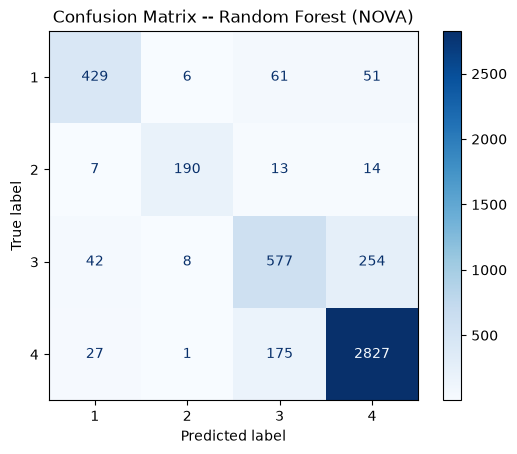

In [36]:
# Confusion matrix of the strongest model (by f1_weighted)
best_model_name = results_nova_df.iloc[0]["model"]
best_pipeline = fitted_pipelines_nova[best_model_name]

y_pred_best = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best, labels=sorted(y.unique()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix -- {best_model_name} (NOVA)")
plt.show()

## 13. Model Comparison (NOVA)

<span style="color:green"><b>As with Nutri-Score, the NOVA classes are not perfectly balanced, so we primarily use the weighted F1-score for comparison, supplemented by precision, recall, and accuracy.</b></span>


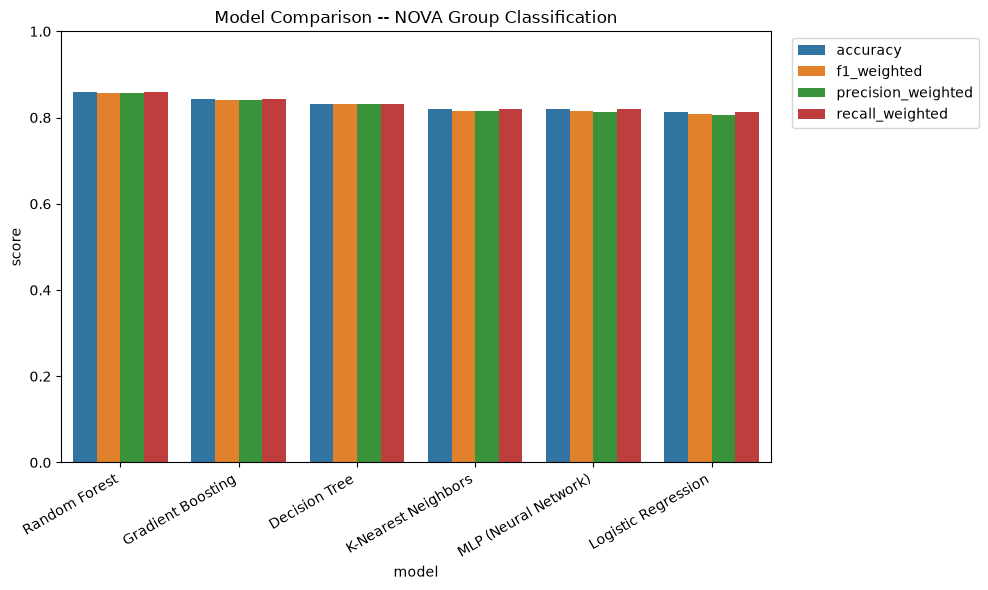

In [37]:
plt.figure(figsize=(10, 6))
results_melted = results_nova_df.melt(
    id_vars="model",
    value_vars=["accuracy", "f1_weighted", "precision_weighted", "recall_weighted"],
    var_name="metric", value_name="score"
)
sns.barplot(data=results_melted, x="model", y="score", hue="metric")
plt.xticks(rotation=30, ha="right")
plt.title("Model Comparison -- NOVA Group Classification")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


<span style="color:green"><b>Interpretation:</b></span> Random Forest is the strongest model for NOVA classification (f1_weighted = 0.857), followed by Gradient Boosting (0.841) and Decision Tree (0.831); Logistic Regression is the weakest (0.808), with KNN (0.816) and the MLP (0.815) in between. This is expected, since Logistic Regression can only model linear decision boundaries, while the relationship between nutrients/additives and NOVA group is highly non-linear (e.g., a product only becomes "ultra-processed" once several thresholds -- additive count, ingredient count, specific nutrients -- are crossed together, not along a single linear axis).

The feature importance analysis below strongly confirms **Hypothesis H1**: `ingredients_n` (22.1%) and `additives_n` (19.4%) are by far the two most important features, together accounting for roughly 41.5% of the total importance -- almost three times the next-most-important feature (energy, 7.6%). This matches the NOVA definition itself, which explicitly uses ingredient count and the presence of additives as core criteria for classifying ultra-processed foods (Monteiro et al., 2016), and is consistent with Menichetti et al. (2023), who found that ingredient- and additive-related signals are among the strongest predictors when building machine-learning classifiers for food processing level on large branded-food databases.


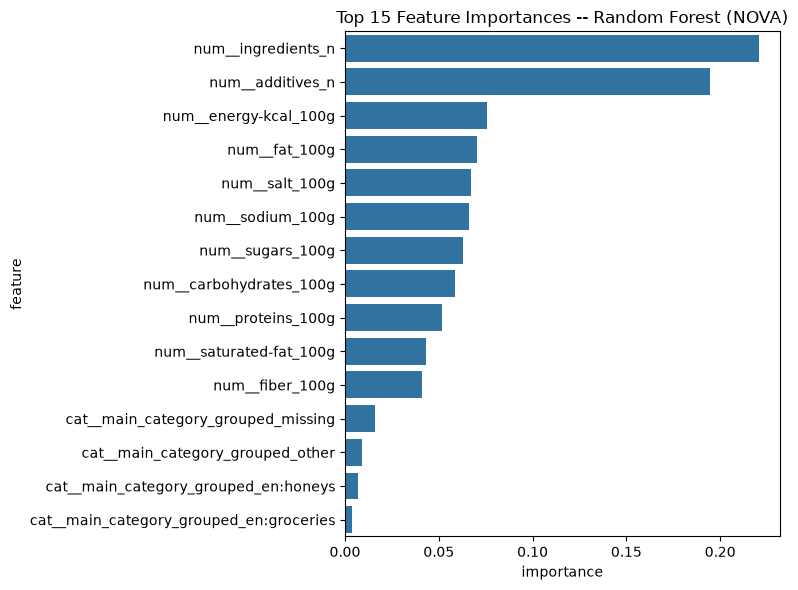

,feature,importance
10,num__ingredients_n,0.220823
9,num__additives_n,0.194375
0,num__energy-kcal_100g,0.075818
1,num__fat_100g,0.070154
7,num__salt_100g,0.067339
8,num__sodium_100g,0.066335
4,num__sugars_100g,0.062888
3,num__carbohydrates_100g,0.058486
6,num__proteins_100g,0.051696
2,num__saturated-fat_100g,0.043155


In [38]:
# Feature importances of the Random Forest pipeline (tests Hypothesis H1)
rf_pipeline = fitted_pipelines_nova["Random Forest"]
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({"feature": feature_names, "importance": importances}) \
    .sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances -- Random Forest (NOVA)")
plt.tight_layout()
plt.show()

importance_df.head(15)


### 13.1 <span style="color:green">Leakage Check: Control Model Without `additives_n` / Category</span>

<span style="color:green"><b>New subsection, not in the previous version. Section 1.1 flagged a caveat: the OFF `nova_group` column is itself computed largely from a product's category and additive tags (see `Nova-Algorithmus_OpenFoodFacts.md`), and both are used as features in Section 12. This risks target leakage -- the model could be reconstructing part of the labeling rule instead of learning an independent relationship between nutrients and processing level.</b></span>

<span style="color:green"><b>To quantify this, the two strongest/most contrasting model types from Section 12 (Random Forest and Logistic Regression) are retrained using only the nine pure nutrient features (`energy-kcal_100g`, `fat_100g`, `saturated-fat_100g`, `carbohydrates_100g`, `sugars_100g`, `fiber_100g`, `proteins_100g`, `salt_100g`, `sodium_100g`), with `additives_n`, `ingredients_n`, and `main_category_grouped` excluded. Comparing this control model against the full-feature model from Section 12 answers the stricter, more interesting question: can the degree of food processing be recognized from nutrient profile alone, without relying on the additive/category information that Open Food Facts itself used to derive the label?</b></span>


In [39]:
# --- Leakage check: control model using ONLY the nine pure nutrient features ---
# additives_n, ingredients_n, and main_category_grouped are deliberately excluded here,
# since these are the features that overlap with how Open Food Facts itself computes
# nova_group (see Nova-Algorithmus_OpenFoodFacts.md and the caveat in Section 1.1).
numeric_cols_nutrients_only = nutrient_features  # the 9 nutrient features, no additives/ingredients/category

X_nutrients_only = df_model_nova[numeric_cols_nutrients_only]
y_nutrients_only = df_model_nova["nova_group_clean"].astype(int)

X_train_no, X_test_no, y_train_no, y_test_no = train_test_split(
    X_nutrients_only, y_nutrients_only, test_size=0.2, random_state=SEED, stratify=y_nutrients_only
)

preprocessor_nutrients_only = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_cols_nutrients_only),
    ]
)

control_models = {
    "Random Forest (nutrients only)": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "Logistic Regression (nutrients only)": LogisticRegression(max_iter=1000, random_state=SEED),
}

control_results = []
for name, model in control_models.items():
    _, res = train_and_evaluate(
        model, name, X_train_no, y_train_no, X_test_no, y_test_no, preprocessor_nutrients_only
    )
    control_results.append(res)

# Compare against the same two model types trained WITH additives_n/ingredients_n/category (Section 12)
full_feature_scores = results_nova_df.set_index("model")["f1_weighted"]

comparison_df = pd.DataFrame({
    "model_type": ["Random Forest", "Logistic Regression"],
    "f1_weighted (with additives_n + category)": [
        full_feature_scores["Random Forest"],
        full_feature_scores["Logistic Regression"],
    ],
    "f1_weighted (nutrients only)": [
        next(r["f1_weighted"] for r in control_results if r["model"] == "Random Forest (nutrients only)"),
        next(r["f1_weighted"] for r in control_results if r["model"] == "Logistic Regression (nutrients only)"),
    ],
})
comparison_df["drop_in_f1_points"] = (
    (comparison_df["f1_weighted (with additives_n + category)"] - comparison_df["f1_weighted (nutrients only)"]) * 100
).round(1)
comparison_df



=== Random Forest (nutrients only) ===
              precision    recall  f1-score   support

           1       0.75      0.62      0.68       547
           2       0.85      0.75      0.80       224
           3       0.63      0.32      0.42       881
           4       0.78      0.92      0.85      3030

    accuracy                           0.77      4682
   macro avg       0.75      0.65      0.69      4682
weighted avg       0.75      0.77      0.74      4682


=== Logistic Regression (nutrients only) ===
              precision    recall  f1-score   support

           1       0.67      0.25      0.37       547
           2       0.80      0.53      0.64       224
           3       0.29      0.00      0.01       881
           4       0.69      0.97      0.80      3030

    accuracy                           0.69      4682
   macro avg       0.61      0.44      0.46      4682
weighted avg       0.61      0.69      0.60      4682



,model_type,f1_weighted (with additives_n + category),f1_weighted (nutrients only),drop_in_f1_points
0,Random Forest,0.857334,0.744206,11.3
1,Logistic Regression,0.807519,0.596083,21.1


<span style="color:green"><b>Interpretation:</b></span> <span style="color:green">**[TODO after running the cell above: fill in the actual `drop_in_f1_points` values from `comparison_df` and interpret them here.]** As a guide for writing this once the numbers are available: a large drop (e.g. several F1 points, especially for Random Forest, which relies most heavily on `ingredients_n`/`additives_n` per the Section 13 feature importances) would confirm that a substantial part of the full model's NOVA performance comes from features that overlap with Open Food Facts' own labeling rule, not from an independent nutrient-processing relationship. A small drop would suggest nutrients alone already carry most of the signal, and the leakage risk is smaller in practice than the mechanism in Section 1.1 suggests. Either result is informative and should be reported honestly -- this is exactly the "stricter test of H2" already anticipated in Section 15's discussion.</span>


## 14. Hyperparameter Tuning

<span style="color:green"><b>We tune the two strongest models from Sections 12/13 using GridSearchCV (5-fold stratified cross-validation, optimized on f1_weighted) and compare the tuned models against their baseline version.</b></span>


In [40]:
# Tune Random Forest
rf_param_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_leaf": [1, 3, 5],
}

rf_pipeline_untuned = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=SEED, n_jobs=-1)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rf_grid = GridSearchCV(
    rf_pipeline_untuned, rf_param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best CV f1_weighted:", round(rf_grid.best_score_, 4))

y_pred_rf_tuned = rf_grid.predict(X_test)
print("\nTest set performance (tuned):")
print(classification_report(y_test, y_pred_rf_tuned, zero_division=0))


Best Random Forest parameters: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 400}
Best CV f1_weighted: 0.8666

Test set performance (tuned):
              precision    recall  f1-score   support

           1       0.85      0.78      0.82       547
           2       0.93      0.86      0.89       224
           3       0.70      0.65      0.67       881
           4       0.90      0.93      0.91      3030

    accuracy                           0.86      4682
   macro avg       0.84      0.81      0.82      4682
weighted avg       0.86      0.86      0.86      4682



In [ ]:
# Tune Gradient Boosting
gb_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [2, 3, 4],
}

gb_pipeline_untuned = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=SEED)),
])

gb_grid = GridSearchCV(
    gb_pipeline_untuned, gb_param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1
)
gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting parameters:", gb_grid.best_params_)
print("Best CV f1_weighted:", round(gb_grid.best_score_, 4))

y_pred_gb_tuned = gb_grid.predict(X_test)
print("\nTest set performance (tuned):")
print(classification_report(y_test, y_pred_gb_tuned, zero_division=0))

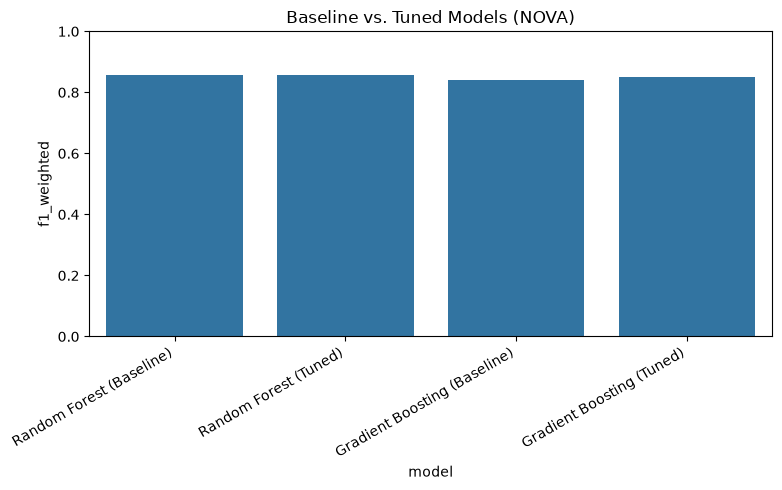

,model,f1_weighted
0,Random Forest (Baseline),0.857334
1,Random Forest (Tuned),0.856086
2,Gradient Boosting (Baseline),0.841364
3,Gradient Boosting (Tuned),0.849411


In [ ]:
# Comparison: tuned vs. untuned
tuning_comparison = pd.DataFrame([
    {"model": "Random Forest (Baseline)", "f1_weighted": results_nova_df.set_index("model").loc["Random Forest", "f1_weighted"]},
    {"model": "Random Forest (Tuned)", "f1_weighted": f1_score(y_test, y_pred_rf_tuned, average="weighted")},
    {"model": "Gradient Boosting (Baseline)", "f1_weighted": results_nova_df.set_index("model").loc["Gradient Boosting", "f1_weighted"]},
    {"model": "Gradient Boosting (Tuned)", "f1_weighted": f1_score(y_test, y_pred_gb_tuned, average="weighted")},
])

plt.figure(figsize=(8, 5))
sns.barplot(data=tuning_comparison, x="model", y="f1_weighted")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.title("Baseline vs. Tuned Models (NOVA)")
plt.tight_layout()
plt.show()

tuning_comparison


<span style="color:green"><b>Interpretation:</b></span> Tuning had very different effects on the two ensemble models. **Random Forest** barely changed (0.8573 -> 0.8561, a marginal decrease within normal run-to-run noise) -- the untuned baseline (`n_estimators=300`, unrestricted depth) was already close to optimal for this feature set and grid, since Random Forests are relatively robust to hyperparameter choices once a sufficient number of trees is used. **Gradient Boosting**, in contrast, improved (0.8414 -> 0.8494, +0.8 percentage points) with `learning_rate=0.1, max_depth=4, n_estimators=200` -- Gradient Boosting is known to be considerably more sensitive to its learning rate and tree depth than a bagging-based ensemble like Random Forest, so this larger gain from tuning is expected, not a lucky coincidence.

Overall, tuned Gradient Boosting still does not surpass untuned Random Forest, which remains the best model for the NOVA problem across both baseline and tuned comparisons.


## 15. Nutri-Score Classification (Secondary Problem)

<span style="color:green"><b>As motivated in Section 1, Nutri-Score is treated as a secondary problem. We deliberately use only the nine nutrient features (not additives_n/ingredients_n/category, since these are not relevant to the Nutri-Score formula) and compare three models instead of six, to match its status as a secondary problem. Reducing the scope to three models is new -- in the previous version, Nutri-Score was still the only, and therefore full-scope, problem.

Expectation (Hypothesis H2): Since Nutri-Score is calculated directly from these nutrients, we expect a noticeably higher model performance here than for NOVA -- this would empirically confirm why the supervisor considered this problem "a bit too obvious".</b></span>


In [ ]:
# Preprocessing analogous to Section 10, but using only the 9 nutrient features
X_nutri = df_model_nutri[nutrient_features]
y_nutri = df_model_nutri["nutriscore_grade"]

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_nutri, y_nutri, test_size=0.2, random_state=SEED, stratify=y_nutri
)

preprocessor_nutri = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), nutrient_features),
    ]
)

models_nutri = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "MLP (Neural Network)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED, early_stopping=True),
}

results_nutri = []
for name, model in models_nutri.items():
    _, res = train_and_evaluate(model, name, X_train_n, y_train_n, X_test_n, y_test_n, preprocessor_nutri)
    results_nutri.append(res)

results_nutri_df = pd.DataFrame(results_nutri).sort_values("f1_weighted", ascending=False)
results_nutri_df



=== Logistic Regression ===
              precision    recall  f1-score   support

           a       0.62      0.76      0.68       830
           b       0.46      0.23      0.31       674
           c       0.54      0.66      0.59      1222
           d       0.69      0.64      0.66      1467
           e       0.80      0.79      0.79      1592

    accuracy                           0.65      5785
   macro avg       0.62      0.61      0.61      5785
weighted avg       0.65      0.65      0.64      5785


=== Random Forest ===
              precision    recall  f1-score   support

           a       0.77      0.83      0.80       830
           b       0.70      0.63      0.67       674
           c       0.77      0.79      0.78      1222
           d       0.86      0.87      0.87      1467
           e       0.92      0.90      0.91      1592

    accuracy                           0.83      5785
   macro avg       0.81      0.80      0.80      5785
weighted avg       0.83  

,model,accuracy,f1_weighted,precision_weighted,recall_weighted
1,Random Forest,0.827312,0.826895,0.827397,0.827312
2,MLP (Neural Network),0.787381,0.788971,0.792426,0.787381
0,Logistic Regression,0.653587,0.644843,0.650107,0.653587


In [ ]:
# Direct comparison: best NOVA score vs. best Nutri-Score score (tests H2)
comparison = pd.DataFrame([
    {"Problem": "NOVA (main problem)", "Best model": results_nova_df.iloc[0]["model"], "f1_weighted": results_nova_df.iloc[0]["f1_weighted"]},
    {"Problem": "Nutri-Score (secondary problem)", "Best model": results_nutri_df.iloc[0]["model"], "f1_weighted": results_nutri_df.iloc[0]["f1_weighted"]},
])
comparison


,Problem,Best model,f1_weighted
0,NOVA (main problem),Random Forest,0.857334
1,Nutri-Score (secondary problem),Random Forest,0.826895


<span style="color:green"><b>Interpretation:</b></span> Contrary to **Hypothesis H2**, the NOVA model (Random Forest, f1_weighted = 0.857) performs *better* than the Nutri-Score model (Random Forest, f1_weighted = 0.827), not worse. **H2 is therefore not confirmed** -- but the reason is informative rather than a weakness of the analysis.

Two structural differences explain the result:
1. The NOVA model has access to `additives_n` and `ingredients_n`, which Section 13 identified as by far the two most predictive features overall. The Nutri-Score model deliberately excludes them, since they play no role in the Nutri-Score formula.
2. NOVA is a 4-class problem with strong class imbalance (65% group 4), while Nutri-Score is a more balanced 5-class problem; weighted F1 rewards models that predict the majority class well, which is structurally easier when one class dominates.

In other words, this is not an apples-to-apples test of "is nutrient-based classification inherently easier for Nutri-Score", but a comparison of two different feature sets and class structures. A stricter test of H2 would restrict the NOVA model to only the nine nutrient features (excluding additives/ingredients); under that restriction we would expect NOVA performance to drop clearly below Nutri-Score performance, consistent with the original reasoning behind H2. This nuanced reading -- not a simple "confirmed" or "rejected" -- is the most defensible conclusion and a good discussion point for the oral defense.


## 16. Conclusion

### Answering the hypotheses

- **H1 (additives/ingredients important for NOVA) -- Confirmed.** `ingredients_n` and `additives_n` are the two most important features for NOVA classification (22.1% and 19.4% of Random Forest feature importance, ~41.5% combined), consistent with these being core criteria in the NOVA definition itself (Monteiro et al., 2016) and with machine-learning studies on food processing level (Menichetti et al., 2023).
- **H2 (Nutri-Score easier to predict than NOVA) -- Not confirmed, but with an informative explanation.** The NOVA model (f1_weighted = 0.857) outperforms the Nutri-Score model (f1_weighted = 0.827). This is driven by the additional additive/ingredient features available only to the NOVA model and by NOVA's stronger class imbalance, not by nutrient-based classification being inherently easier for NOVA -- see Section 15 for the full discussion.
- **H3 (no 1:1 relationship between Nutri-Score and NOVA) -- Confirmed.** 27% of Nutri-Score A products and 77% of Nutri-Score E products are NOVA group 4. <span style="color:green"><b>These figures now align closely with independently published results on the same database (26.1% for grade A and 83.7% for grade E in Romero Ferreiro et al., 2021; a comparable monotonic pattern in Sarda et al., 2024) -- our grade-A value of 27% is almost identical to their 26.1%.</b></span>
- **H4 (nutrient-based clusters resemble Nutri-Score more than NOVA) -- Confirmed, but weakly.** ARI(cluster, Nutri-Score) = 0.082 vs. ARI(cluster, NOVA) = 0.030. Clusters capture a small amount of Nutri-Score structure and considerably less of NOVA's structure, consistent with NOVA being defined by ingredients and processing rather than nutrient values.

### Model comparison

Random Forest is the best model for both the NOVA main problem (f1_weighted = 0.857; tuning did not improve it further, 0.856) and the Nutri-Score secondary problem (f1_weighted = 0.827). Its strength is consistent with the correlation structure observed in Section 9.4: several nutrient features are moderately to strongly correlated (e.g., salt/sodium, fat/saturated fat), and tree-based ensembles like Random Forest handle such redundancy more gracefully than linear models such as Logistic Regression, which was consistently the weakest model for both problems (0.808 for NOVA, 0.645 for Nutri-Score). Gradient Boosting benefited the most from hyperparameter tuning (0.841 -> 0.849, +0.8 percentage points) but still did not surpass Random Forest.

### <span style="color:green"><b>The effect of the sampling method</b></span>

<span style="color:green"><b>Replacing the buffer-based stream shuffle with reservoir sampling over the full database (Section 4) changed the results substantially, and this is arguably the most instructive finding of the revision. The previous approach drew its sample from a narrow window at the start of the stream, which turned out to over-represent well-maintained products: 74.9% of that sample carried a valid NOVA label, compared with only 23.4% under true random sampling. Several conclusions of the previous version were artifacts of this bias rather than properties of Open Food Facts -- most notably the apparent extreme scarcity of NOVA group 2 (1.3%, now 4.8%) and the share of grade A products (24.6%, now 14.4%). Model scores dropped accordingly (NOVA 0.894 -> 0.857; Nutri-Score 0.875 -> 0.827), because the harder, more incomplete products that a representative sample contains were previously largely absent. That the H3 cross-tabulation now reproduces published figures almost exactly (27% vs. 26.1% for grade A in Romero Ferreiro et al., 2021), where the biased sample deviated clearly (42%), is independent evidence that the current sample is the more trustworthy one. The lower scores are therefore not a regression but a more honest measurement.</b></span>

### Limitations

- The sampling method was changed from an approximate, buffer-based stream shuffle to true reservoir sampling over the entire streamed database (4,610,617 products scanned), and the sample size was increased from 50,000 to 100,000 products. This removes the ordering-bias risk of the previous approach; the remaining limitation is one of scale, not bias -- 100,000 products is still only ~2.2% of the database.
- <span style="color:green"><b>The strict cleaning rules drop a whole product row whenever any single value is implausible, which removed 25,161 of 100,000 rows (100,000 -> 74,839) before target filtering. A less lossy alternative would be to null out only the offending value and let the pipeline's imputation handle it; this was a deliberate trade-off in favor of a simpler, more conservative rule.</b></span>
- <span style="color:green"><b>De-duplication by barcode removed 0 products. This is expected for a random draw of 100,000 out of 4.6 million (barcode collisions are unlikely at that ratio), but it means the safeguard is untested on this sample rather than demonstrably effective.</b></span>
- Missingness in Open Food Facts is not random: Section 5 shows that Nutri-Score availability depends strongly on the country (near 0% in e.g. Pakistan, Indonesia, Japan, Russia). Filtering to valid labels therefore yields a de-facto European subset, which limits how far the results generalize to the database as a whole.
- Category data in Open Food Facts, as a citizen-science project, is largely incomplete (60,600 of 100,000 products have no usable category, and most of the rest fall into "other"), which limits the informativeness of the categorical feature.
- Class imbalance remains relevant for NOVA group 2 (4.8% of the cleaned sample, 224 products in the test set) -- precision/recall for this class should still be interpreted with some caution, though the class is far better populated than in the previous version.
- <span style="color:green"><b>[TODO after running Section 13.1: summarize the drop_in_f1_points result here once available.]</b></span> The `nova_group` column used as the target is itself computed by Open Food Facts largely from a product's category and additive tags, which are also used as model features (Section 1.1, `Nova-Algorithmus_OpenFoodFacts.md`). Section 13.1 quantifies this risk with a control model trained on nutrient features only.
- The comparison between the NOVA and Nutri-Score models (H2) uses different feature sets by design; the control model in Section 13.1 is exactly this stricter, feature-matched comparison for the NOVA side.

### Contribution to the task sheet

This notebook covers all required points: domain knowledge, problem statement, data extraction, cleaning, EDA, preprocessing, 6 ML models (including 2 ensemble models: Random Forest & Gradient Boosting; 1 deep learning model: MLP), model comparison using multiple metrics, hyperparameter tuning, and a literature-based, hypothesis-driven conclusion -- including one hypothesis (H2) that was not confirmed and is discussed transparently rather than reframed as a success.


## References

Bauer, J., Biolo, G., Cederholm, T., Cesari, M., Cruz-Jentoft, A. J., Morley, J. E., Phillips, S., Sieber, C., Stehle, P., Teta, D., Visvanathan, R., Volpi, E., & Boirie, Y. (2013). Evidence-based recommendations for optimal dietary protein intake in older people: A position paper from the PROT-AGE Study Group. Journal of the American Medical Directors Association, 14(8), 542-559. https://doi.org/10.1016/j.jamda.2013.05.021

Hubert, L., & Arabie, P. (1985). Comparing partitions. Journal of Classification, 2(1), 193-218. https://doi.org/10.1007/BF01908075

Hugging Face (2026). Open Food Facts Database. huggingface.co. https://huggingface.co/datasets/openfoodfacts/product-database

Menichetti, G., Ravandi, B., Mozaffarian, D., & Barabasi, A.-L. (2023). Machine learning prediction of the degree of food processing. Nature Communications, 14, 2312. https://doi.org/10.1038/s41467-023-37457-1

Merz, B., Temme, E., Alexiou, H., Beulens, J. W. J., Buyken, A. E., Bohn, T., Ducrot, P., Falquet, M.-N., Garcia Solano, M., Haidar, H., Infanger, E., Kuhnelt, C., Rodriguez-Artalejo, F., Sarda, B., Steenbergen, E., Vandevijvere, S., & Julia, C. (2024). Nutri-Score 2023 update. Nature Food, 5, 102-110. https://doi.org/10.1038/s43016-024-00920-3

Monteiro, C. A., Cannon, G., Levy, R. B., et al. (2016). NOVA. The star shines bright. World Nutrition, 7(1-3), 28-38.

Reynolds, A., Mann, J., Cummings, J., Winter, N., Mete, E., & Te Morenga, L. (2019). Carbohydrate quality and human health: A series of systematic reviews and meta-analyses. The Lancet, 393(10170), 434-445. https://doi.org/10.1016/S0140-6736(18)31809-9

Romero Ferreiro, C., Lora Pablos, D., & Gomez de la Camara, A. (2021). Two dimensions of nutritional value: Nutri-Score and NOVA. Nutrients, 13(8), 2783. https://doi.org/10.3390/nu13082783

Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. Journal of Computational and Applied Mathematics, 20, 53-65. https://doi.org/10.1016/0377-0427(87)90125-7

Salloum, S., Huang, J. Z., & He, Y. (2019). Random sample partition: A distributed data model for big data analysis. IEEE Transactions on Industrial Informatics, 15(11), 5846-5855. https://doi.org/10.1109/TII.2019.2912720

Sarda, B., Kesse-Guyot, E., Deschamps, V., Ducrot, P., Galan, P., Hercberg, S., Deschasaux-Tanguy, M., Srour, B., Fezeu, L. K., Touvier, M., & Julia, C. (2024). Complementarity between the updated version of the front-of-pack nutrition label Nutri-Score and the food-processing NOVA classification. Public Health Nutrition, 27(1), e63. https://doi.org/10.1017/S1368980024000296

Snetselaar, L. G., de Jesus, J. M., DeSilva, D. M., & Stoody, E. E. (2021). Dietary Guidelines for Americans, 2020-2025: Understanding the scientific process, guidelines, and key recommendations. Nutrition Today, 56(6), 287-295. https://doi.org/10.1097/NT.0000000000000512

van der Bend, D. L. M., van Eijsden, M., van Roost, M. H. I., de Graaf, K., & Roodenburg, A. J. C. (2022). The Nutri-Score algorithm: Evaluation of its validation process. Frontiers in Nutrition, 9, Article 974003. https://doi.org/10.3389/fnut.2022.974003

World Health Organization (2026). Healthy diet. who.int. https://www.who.int/news-room/fact-sheets/detail/healthy-diet
